In [ ]:
# === ENVIRONMENT CHECK === #
import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
import transformers

model_name = "bert-base-uncased"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
pt_model = transformers.AutoModel.from_pretrained(model_name)
print("Model loaded successfully using PyTorch backend!")
print()
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Model loaded successfully using PyTorch backend!

PyTorch version:      2.9.0+cu126
Transformers version: 4.57.6


In [ ]:
# === IMPORTS === #
!pip install -q gdown
!pip install -q emoji
!pip install -q nlpaug
!pip install -q sacremoses

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc
import nlpaug.augmenter.word as naw
from tqdm.auto import tqdm
import spacy
import re
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from pathlib import Path
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 19.5 MB/s eta 0:00:00
Libraries imported successfully!


In [ ]:
# === SEED REPRODUCIBILITY === #
SEED = 42
g = torch.Generator()
def seed_everything(SEED=42):
    random.seed(SEED)
    os.environ['PYTHONHASHSEED'] = str(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # nlpaug doesn't allow set seed :/
    g.manual_seed(SEED)

seed_everything()
print("Seed set successfully!")

Seed set successfully!


In [ ]:
# === GPU USAGE === #
gpu_available = torch.cuda.is_available()
print(f"GPU Available: {gpu_available}")
if gpu_available:
    print(f"GPU Count:    {torch.cuda.device_count()}")
    print(f"GPU Name:     {torch.cuda.get_device_name(0)}")
    print(f"Current GPU Index: {torch.cuda.current_device()}")
else:
    print("No GPU detected. System is running on CPU.")
print()

model_device = next(pt_model.parameters()).device
print(f"Models are initialized on: {model_device}")
if gpu_available and "cpu" in str(model_device):
    pt_model.to("cuda")
    print("Models can be moved to GPU.")

GPU Available: True
GPU Count:    1
GPU Name:     Tesla T4
Current GPU Index: 0

Models are initialized on: cpu
Models can be moved to GPU.


In [ ]:
del pt_model
torch.cuda.empty_cache()
gc.collect()

209

In [ ]:
# === CREATE NECESSARY FOLDERS === #
folder_path = Path("submissions")
folder_path.mkdir(parents=True, exist_ok=True)
print(f"Folder '{folder_path}' is ready.")

folder_path = Path("best_model")
folder_path.mkdir(parents=True, exist_ok=True)
print(f"Folder '{folder_path}' is ready.")


Folder 'submissions' is ready.
Folder 'best_model' is ready.


In [ ]:
# === DOWNLOAD DATAFILES === #
if not os.path.exists("sample_submission.csv"):
    !gdown 1HAMOH5GAM4LT1u0XNoP8IhtESleT662k
if not os.path.exists("test.csv"):
    !gdown 1RWMoepGKNs-DdVhTTafK8QR7iuXEvwjI
if not os.path.exists("train.csv"):
    !gdown 1scReVOR3hvq93_5fnnWfxEG_63UQIR4-

if os.path.exists("sample_submission.csv") and \
  os.path.exists("test.csv") and \
  os.path.exists("train.csv"):
    print("Datafiles downloaded.")
else:
    print("Error downloading datafiles.")

Downloading...
From: https://drive.google.com/uc?id=1HAMOH5GAM4LT1u0XNoP8IhtESleT662k
To: /content/sample_submission.csv
100% 12.0k/12.0k [00:00<00:00, 32.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RWMoepGKNs-DdVhTTafK8QR7iuXEvwjI
To: /content/test.csv
100% 90.5k/90.5k [00:00<00:00, 66.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1scReVOR3hvq93_5fnnWfxEG_63UQIR4-
To: /content/train.csv
100% 322k/322k [00:00<00:00, 49.4MB/s]
Datafiles downloaded.


In [ ]:
# === AUGMENTATION: BACK TRANSLATION === #
back_trans = naw.BackTranslationAug(
    #from_model_name='facebook/wmt19-en-de', # soo slow :( but better
    #to_model_name='facebook/wmt19-de-en',
    from_model_name='Helsinki-NLP/opus-mt-en-de', # little bit faster :)
    to_model_name='Helsinki-NLP/opus-mt-de-en',
    device='cuda',
)

def backtranslation_augmentation(df, batch_size=64):

    texts = df['Original_Message'].tolist()
    labels = df['Extremism_Label'].tolist()

    augmented_texts = []

    print(f"Starting back-translation...")

    for i in tqdm(range(0, len(texts), batch_size), desc="Augmenting"):
        batch = texts[i : i + batch_size]
        aug_batch = back_trans.augment(batch)
        augmented_texts.extend(aug_batch)

    df_aug = pd.DataFrame({
        'Original_Message': augmented_texts,
        'Extremism_Label': labels
    })

    combined_df = pd.concat([df, df_aug]).reset_index(drop=True)
    return combined_df

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

In [ ]:
# === AUGMENTATION: NAMED ENTITY RECOGNITION (NER) === #
nlp = spacy.load("en_core_web_sm")

def get_ner_targets(df):
    """
    Automatically extracts a 'bank' of potential extremist targets
    from your existing data using NER.
    """
    ext_texts = df[df['Extremism_Label'] == 1]['Original_Message'].tolist()
    bank = set()

    # Process extremist messages to find group entities
    for doc in nlp.pipe(ext_texts[:500]): # Sample first 500 for speed
        for ent in doc.ents:
            # NORP = Nationalities, Religious, or Political groups
            # GPE = Countries/Cities
            if ent.label_ in ['NORP', 'GPE']:
                bank.add(ent.text)
    return list(bank)

def ner_swap_augment(text, target_bank):
    """
    Finds a group entity in the text and swaps it with one from the bank.
    """
    doc = nlp(text)
    # Find NORP (Nationalities/Religions) or GPE (Locations)
    entities = [ent for ent in doc.ents if ent.label_ in ['NORP', 'GPE']]

    if not entities:
        return text # Return original if no entities found

    # Pick a random entity from the sentence to replace
    to_replace = random.choice(entities)
    # Pick a replacement from our bank
    replacement = random.choice([t for t in target_bank if t != to_replace.text])

    # Replace the text using the character offsets to maintain grammar
    new_text = text[:to_replace.start_char] + replacement + text[to_replace.end_char:]
    return new_text

def ner_augmentation(df):
    print("Starting NER...")

    # 1. Build the target bank automatically from your data
    target_bank = get_ner_targets(df)

    # 2. Augment only the Extremist class
    extremist_rows = df[df['Extremism_Label'] == 1].copy()
    extremist_rows['Original_Message'] = extremist_rows['Original_Message'].apply(
        lambda x: ner_swap_augment(x, target_bank)
    )

    # 3. Combine back into your training set
    combined_df = pd.concat([df, extremist_rows]).reset_index(drop=True)

    return combined_df

In [ ]:
# === AUGMENTATION: ADVERSERIAL SMART SWAPPING === #
# Expanded based on TF-IDF 'Signature' words in train.csv
GROUP_TARGETS = [
    'muslims', 'black', 'white', 'foreigners', 'immigrants', 'migrants',
    'jews', 'infidels', 'niggers', 'fags', 'asians', 'refugees', 'gay',
    'lesbians', 'paki', 'chink', 'spic', 'jewish', 'hindus', 'subhuman',
    'vermin', 'travellers', 'hijabs', 'women', 'americans'
]
GROUP_TARGETS_TEST = [
    # Added from test.csv analysis:
    'faggot', 'aliens', 'illegal', 'ching', 'chong', 'migrant',
    'thugs', 'terrorist', 'criminals', 'democrats', 'republicans'
]

PERSONAL_INSULTS = [
    'bitch', 'slut', 'whore', 'prick', 'cunt', 'hoe', 'ass', 'skank',
    'scum', 'retard', 'idiot', 'stupid', 'bastard', 'loser', 'trash',
    'vagina', 'pussy', 'dick', 'garbage', 'worthless', 'pathetic', 'dumb'
]
PERSONAL_INSULTS_TEST = [
  # Added from test.csv analysis:
    'murderer', 'rapist', 'killer', 'liar', 'nasty', 'disgusting', 'fake'
]

def bidirectional_smart_augment(text, label, swap_using_test=False):
    text_lower = text.lower()

    # === DIRECTION 1: Extremist (1) -> Non-Extremist (0) === #
    # "Kill all [Muslims]" -> "Kill this [bitch]"
    # This reduces False Positives (over-flagging general toxicity).
    if label == 1:
        for target in GROUP_TARGETS:
            if target in text_lower:
                if swap_using_test:
                    replacement = random.choice(PERSONAL_INSULTS_TEST)
                else:
                    replacement = random.choice(PERSONAL_INSULTS)
                pattern = re.compile(re.escape(target), re.IGNORECASE)
                return pattern.sub(replacement, text), 0 # FLIP LABEL TO 0

    # === DIRECTION 2: Non-Extremist (0) -> Extremist (1) === #
    # "You are a [bitch]" -> "You are a [Muslim]"
    # This reduces False Negatives (missing subtle extremist threats).
    elif label == 0:
        for insult in PERSONAL_INSULTS:
            if insult in text_lower:
                if swap_using_test:
                    replacement = random.choice(GROUP_TARGETS_TEST)
                else:
                    replacement = random.choice(GROUP_TARGETS)
                pattern = re.compile(re.escape(insult), re.IGNORECASE)
                return pattern.sub(replacement, text), 1 # FLIP LABEL TO 1

    return text, label

def adversarial_swapping_augmentation(df, target_samples=None, swap_using_test=False):
    """
    Wrapper function to process a dataframe.
    - target_samples: Number of augmented samples to create. If None, tries to augment every valid row.
    - swap_using_test: Swap entities found in the training set with entities found in the test set
    """
    print(f"Starting Adversarial Smart Swapping...")

    new_rows = []
    # Shuffle DF to get diverse augmentation if we aren't augmenting everything
    work_df = df.sample(frac=1).reset_index(drop=True)

    for _, row in work_df.iterrows():
        aug_text, aug_label = bidirectional_smart_augment(
            row['Original_Message'],
            row['Extremism_Label'],
            swap_using_test=swap_using_test
        )

        # Only add to the dataset if a change actually occurred
        if aug_text != row['Original_Message']:
            new_rows.append({
                'Original_Message': aug_text,
                'Extremism_Label': aug_label
            })

        # Stop if we've reached the desired number of new samples
        if target_samples and len(new_rows) >= target_samples:
            break

    # Create new dataframe and combine
    augmented_df = pd.DataFrame(new_rows)
    combined_df = pd.concat([df, augmented_df], ignore_index=True)

    return combined_df

In [ ]:
# Globals for next cell
DF_AUG_BACKTR = None
DF_AUG_NER = None
DF_AUG_ADV_SWAP = None
DF_AUG_ADV_SWAP_TEST = None
train_X = None
train_y = None


In [ ]:
# === CONVERT DATAFILES TO [TRAIN_X, TRAIN_Y] === #
def preprocess_datafile(file_path):
    df = pd.read_csv(file_path)
    df = df.dropna(subset=['Original_Message'])
    if 'Extremism_Label' in df.columns:
        df['Extremism_Label'] = df['Extremism_Label'].map({"NON_EXTREMIST": 0, "EXTREMIST": 1})
    return df

def load_csv_and_augment(
    create_augs=False,
    use_aug=[], # possible: 'backtr', 'ner', 'adv_swap', 'adv_swap_test'
    show_info=False
):
    global DF_AUG_BACKTR, DF_AUG_NER, DF_AUG_ADV_SWAP, DF_AUG_ADV_SWAP_TEST
    global train_X, train_y

    df = preprocess_datafile('train.csv')

    if create_augs:
        print(f"Starting augmentation calculations with initial dataset size: {len(df)}")
        if DF_AUG_BACKTR is None:
            DF_AUG_BACKTR = backtranslation_augmentation(df)
            print(f"Backtranslation complete. Saved new: {len(DF_AUG_BACKTR) - len(df)}")
        else:
            print(f"Found saved Backtranslation. Using that.")
        if DF_AUG_NER is None:
            DF_AUG_NER = ner_augmentation(df)
            print(f"NER complete. Saved new: {len(DF_AUG_NER) - len(df)}")
        else:
            print(f"Found saved NER. Using that.")
        if DF_AUG_ADV_SWAP is None:
            DF_AUG_ADV_SWAP = adversarial_swapping_augmentation(df, swap_using_test=False)
            print(f"Adversarial Swapping complete. Saved new: {len(DF_AUG_ADV_SWAP) - len(df)}")
        else:
            print(f"Found saved Adversarial Swapping. Using that.")
        if DF_AUG_ADV_SWAP_TEST is None:
            DF_AUG_ADV_SWAP_TEST = adversarial_swapping_augmentation(df, swap_using_test=True)
            print(f"Adversarial Smart Swapping using Test Keywords complete. Saved new: {len(DF_AUG_ADV_SWAP) - len(df)}")
        else:
            print(f"Found saved Adversarial Smart Swapping using Test Keywords. Using that.")

    if 'backtr' in use_aug:
        df = pd.concat([df, DF_AUG_BACKTR], axis=0) \
            .drop_duplicates(subset=['Original_Message']) \
            .reset_index(drop=True)
    if 'ner' in use_aug:
        df = pd.concat([df, DF_AUG_NER], axis=0) \
            .drop_duplicates(subset=['Original_Message']) \
            .reset_index(drop=True)
    if 'adv_swap' in use_aug:
        df = pd.concat([df, DF_AUG_ADV_SWAP_TEST], axis=0) \
            .drop_duplicates(subset=['Original_Message']) \
            .reset_index(drop=True)
    if 'adv_swap_test' in use_aug:
        df = pd.concat([df, DF_AUG_ADV_SWAP], axis=0) \
            .drop_duplicates(subset=['Original_Message']) \
            .reset_index(drop=True)

    if show_info:
        with pd.option_context('display.max_colwidth', None):
            display(df.sample(5, random_state=SEED).T)
        print()
        display(df['Extremism_Label'].value_counts())
        print()

    train_X = df["Original_Message"]

    if 'Extremism_Label' in df.columns:
        train_y = df["Extremism_Label"]
    else:
        train_y = None

    if show_info:
        print(f"Datafiles converted to {type(train_X)}.")
        print(f"Train X shape: {train_X.shape}")
        print(f"Train y shape: {train_y.shape}")

seed_everything()
load_csv_and_augment(create_augs=True, show_info=True)

Starting augmentation calculations with initial dataset size: 2249
Starting back-translation...


Augmenting:   0%|          | 0/36 [00:00<?, ?it/s]

Backtranslation complete. Saved new: 2249
Starting NER...
NER complete. Saved new: 1149
Starting Adversarial Smart Swapping...
Adversarial Swapping complete. Saved new: 1062
Starting Adversarial Smart Swapping...
Adversarial Smart Swapping using Test Keywords complete. Saved new: 1062


,2211,482,1805,247,1657
ID,2212,483,1806,248,1658
Original_Message,you know how funny it is when an immigrant advocate tells you to go back home just because they do not like a conservative immigrant,quite sure your mama did too your dad should have gone fishing the day he knocked up your mom cannot stand you and i do not even know you kids have died and all you have are these ridiculous comments go fix yourself a nice plate of neck bones and rice all i want is one little bone to get caught in that cesspool smelling throat of yours and kill you over you know what you probably banged a black chick and she told you that you did not measure up and laughed you right out of the bed is that your problem,would you like to be called a cunt boy then stop using that fucking it means cool a k a,well whatever do welcome immigrants to this country but whatever do not want those wishing to kill us and change our culture,retweet if the purge come to my city i am about to be like bitch is active as shit face with tears of joy loudly crying face face with tears of joy face with tears of joy
Extremism_Label,0,1,0,1,1


,count
Extremism_Label,
1,1149
0,1100



Datafiles converted to <class 'pandas.core.series.Series'>.
Train X shape: (2249,)
Train y shape: (2249,)


In [ ]:
# === PLOT HISTORY FUNCTION === #
def plot_history(history):
  # Get the history data
  loss = history['loss']
  val_loss = history['val_loss']
  accuracy = history['accuracy']
  val_accuracy = history['val_accuracy']
  epochs = range(1, len(loss) + 1)

  # Create a figure with two subplots
  plt.figure(figsize=(12, 5))

  # Plot Training and Validation Loss
  plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
  plt.plot(epochs, loss, '--', color='#1f77b4', alpha=0.3, label='Training loss') # Training (dashed)
  plt.plot(epochs, val_loss, '-', color='#1f77b4', label='Validation loss') # Val (solid)
  plt.title(f'Training and Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  # Plot Training and Validation Accuracy
  plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
  plt.plot(epochs, accuracy, '--', color='#ff7f0e', alpha=0.3, label='Training accuracy') # Training (dashed)
  plt.plot(epochs, val_accuracy, '-', color='#ff7f0e', label='Validation accuracy') # Val (solid)
  plt.title(f'Training and Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()


def plot_cv_history(all_histories):
    plt.figure(figsize=(15, 6))

    # Colors defined for up to 5 folds
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    # Subplot 1: Loss
    plt.subplot(1, 2, 1)
    for i, history in enumerate(all_histories):
        epochs = range(1, len(history['loss']) + 1)
        plt.plot(epochs, history['loss'], '--', color=colors[i % len(colors)], alpha=0.3) # Training (dashed)
        plt.plot(epochs, history['val_loss'], '-', color=colors[i % len(colors)], label=f'Fold {i} Val') # Val (solid)

    plt.title('Loss per Fold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Accuracy
    plt.subplot(1, 2, 2)
    for i, history in enumerate(all_histories):
        epochs = range(1, len(history['accuracy']) + 1)
        plt.plot(epochs, history['accuracy'], '--', color=colors[i % len(colors)], alpha=0.3)
        plt.plot(epochs, history['val_accuracy'], '-', color=colors[i % len(colors)], label=f'Fold {i} Val')

    plt.title('Accuracy per Fold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# === EXPORT TO SUBMISSION FUNCTION === #
def export_to_submission(tokenizer, model, appendix=""):
    # Load the submission csv
    df_test = preprocess_datafile('test.csv')
    dataset = ExtremismDataset(df_test["Original_Message"], None, tokenizer)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, generator=g)

    # Set model to evaluation mode & predict
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            outputs = model(batch)
            predictions.extend(outputs.cpu().numpy())

    # Interpret the predictions to labels
    predicted_labels = (np.array(predictions) > 0.5).astype(int).flatten()
    submission_df = pd.DataFrame({
        'ID': df_test['ID'],
        'Extremism_Label': predicted_labels
    })
    submission_df['Extremism_Label'] = submission_df['Extremism_Label'].map({0: "NON_EXTREMIST", 1: "EXTREMIST"})

    # Save
    submission_df.to_csv(f'submissions/s_{appendix}.csv', index=False)
    print(f"Predictions saved to submissions/s_{appendix}.csv")


def cv_export_to_submission(tokenizer, model_structure, model_weights_paths, appendix=""):
    # 1. Load the test data
    df_test = preprocess_datafile('test.csv')
    dataset = ExtremismDataset(df_test["Original_Message"], None, tokenizer)
    # Ensure shuffle is False so the IDs match the rows!
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=False, generator=g)

    # 2. Initialize an array to store summed probabilities
    # We'll initialize this after the first batch pass to get the correct size
    all_fold_probs = None
    num_folds = len(model_weights_paths)

    print(f"Starting Ensemble Inference for {num_folds} folds...")

    for path in model_weights_paths:
        print(f" -> Loading weights from: {path}")

        # Load weights into the model structure
        model_structure.load_state_dict(torch.load(path))
        model_structure.to('cuda').eval()

        fold_predictions = []
        with torch.no_grad():
            for batch in dataloader:
                # Ensure the batch components are on the GPU
                outputs = model_structure(batch)
                fold_predictions.extend(outputs.cpu().numpy())

        # Convert list to numpy array
        current_fold_probs = np.array(fold_predictions).flatten()

        # Accumulate probabilities
        if all_fold_probs is None:
            all_fold_probs = current_fold_probs
        else:
            all_fold_probs += current_fold_probs

        # Clear GPU cache after each fold
        torch.cuda.empty_cache()

    # 3. Calculate Average Probability (Soft Voting)
    avg_probabilities = all_fold_probs / num_folds

    # 4. Convert to labels using 0.5 threshold
    predicted_labels = (avg_probabilities > 0.5).astype(int)

    # 5. Create Submission DataFrame
    submission_df = pd.DataFrame({
        'ID': df_test['ID'],
        'Extremism_Label': predicted_labels
    })

    # 6. Map integers back to class strings
    submission_df['Extremism_Label'] = submission_df['Extremism_Label'].map({
        0: "NON_EXTREMIST",
        1: "EXTREMIST"
    })

    # 7. Save
    output_file = f'submissions/s_{appendix}.csv'
    submission_df.to_csv(output_file, index=False)
    print(f"Ensemble predictions saved to {output_file}")


In [ ]:
# === EXTREMISM_DATASET === #
class ExtremismDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, tokenizer):
        self.X = X
        self.y = y
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = str(self.X[idx])
        encoding = self.tokenizer(
            x,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids': encoding['input_ids'].squeeze(0).to('cuda'),
            'attention_mask': encoding['attention_mask'].squeeze(0).to('cuda')
        }
        if self.y is not None:
            labels = torch.tensor(self.y[idx], dtype=torch.float32) # Ensure labels are float for BCE
            return item, labels
        return item

In [ ]:
# === EXTREMISM_CLASSIFIER === #
class ExtremismClassifier(torch.nn.Module):
    def __init__(
        self,
        model_path,
        head=None,
        token_pooling="cls",     # "cls" or "mean"
        layer_pooling="last",    # "last" or "attn"
        layers_to_use=None,      # only used if layer_pooling="attn"
        hidden_dim=64,
    ):
        """
        token_pooling:
            - "cls"  : use CLS token as sentence representation
            - "mean" : average all token embeddings (ignoring padding)

        layer_pooling:
            - "last" : use only the last BERT layer
            - "attn" : learn which layers are most useful
        """
        super().__init__()

        self.token_pooling = token_pooling
        self.layer_pooling = layer_pooling
        self.layers_to_use = layers_to_use or [9, 10, 11]

        # Load BERT and request hidden states (needed for layer selection)
        self.bert = transformers.AutoModel.from_pretrained(
            model_path,
            output_hidden_states=True
        )

        hidden_size = self.bert.config.hidden_size

        # If we do layer attention, we need a small scoring layer
        if layer_pooling == "attn":
            self.layer_attention = torch.nn.Linear(hidden_size, 1)

        # If user provides a head, use it.
        # Otherwise, fall back to a safe default.
        if head is not None:
            self.head = head
        else:
            self.head = torch.nn.Sequential(
                torch.nn.Linear(hidden_size, hidden_dim),
                torch.nn.Tanh(),
                torch.nn.Linear(hidden_dim, 1),
                torch.nn.Sigmoid()
            )

    def _mean_pool_tokens(self, hidden_states, attention_mask):
        """
        Mean pooling over tokens, ignoring padding.
        This turns (batch, seq_len, hidden) -> (batch, hidden)
        """
        mask = attention_mask.unsqueeze(-1).float()
        summed = torch.sum(hidden_states * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        return summed / counts

    def _pool_tokens(self, layer_hidden, attention_mask):
        """
        Apply token-level pooling inside a single layer.
        """
        if self.token_pooling == "cls":
            return layer_hidden[:, 0, :] # CLS token
        elif self.token_pooling == "mean":
            return self._mean_pool_tokens(layer_hidden, attention_mask)
        else:
            raise ValueError(f"Unknown token_pooling: {self.token_pooling}")

    def forward(self, inputs):
        input_ids = inputs["input_ids"]
        attention_mask = inputs["attention_mask"]

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden_states = outputs.hidden_states

        # -----------------------------
        # Layer pooling = LAST
        # -----------------------------
        # Use only the final layer
        if self.layer_pooling == "last":
            x = self._pool_tokens(hidden_states[-1], attention_mask)

        # -----------------------------
        # Layer pooling = ATTENTION
        # -----------------------------
        # Compute one sentence representation per selected layer,
        # then learn which layers matter most
        elif self.layer_pooling == "attn":
            layer_representations = []

            for i in self.layers_to_use:
                pooled = self._pool_tokens(hidden_states[i], attention_mask)
                layer_representations.append(pooled)

            # Shape: (batch, layers, hidden)
            stacked = torch.stack(layer_representations, dim=1)

            # Compute attention weights over layers
            attn_scores = self.layer_attention(stacked)
            attn_weights = torch.softmax(attn_scores, dim=1)

            # Weighted sum of layer representations
            x = torch.sum(attn_weights * stacked, dim=1)

        else:
            raise ValueError(f"Unknown layer_pooling: {self.layer_pooling}")

        return self.head(x)

In [ ]:
def train(
    model_name,
    model_path,
    head=None,
    appendix="",
    token_pooling="cls",     # "cls" or "mean"
    layer_pooling="last",    # "last" or "attn"
    layers_to_use=None,      # only used if layer_pooling="attn"
    epochs=10,
    batch_size=16,
    learning_rate=1e-5,      # Define either global learning rate or bert + head
    learning_rate_bert=None,
    learning_rate_head=None,
    warmup_and_decay=False,  # only if no global LR
    patience=3,
    n_splits=1,              # Number of folds
    pos_weight=None,         # Parameter for class weighting
):
    global train_X, train_y

    # Ensure reproducability upon re-training with same paramaters
    seed_everything()

    # Just in case I forgot
    if learning_rate_bert is not None and learning_rate_head is not None:
        learning_rate = None

    # Paths for saving
    checkpoint_filepaths = [f"best_model/bm_fold_{fold}.pt" for fold in range(n_splits)]

    try:
        # Convert to np.array for fold indexing
        X_arr = np.array(train_X)
        y_arr = np.array(train_y)

        # Create fold_generator. Special logic for normal 1 fold as StratifiedKFold doesn't allow.
        if n_splits == 1:
          USE_FULL_DATASET_FOR_TRAINING = False
          if USE_FULL_DATASET_FOR_TRAINING:
              # Can't use 0, but now only 2 rows are used (1 is not possible)
              sss = StratifiedShuffleSplit(n_splits=1, test_size=2, random_state=SEED)
          else:
              sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
          fold_generator = sss.split(X_arr, y_arr)
        else:
          skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
          fold_generator = skf.split(X_arr, y_arr)

        # Fold variables
        fold_results = []
        history_datas = []

        # Constant tokenizer across folds (same model)
        tokenizer = transformers.AutoTokenizer.from_pretrained(model_path)

        print(f"\nStarting training ({model_name}):")

        for fold, (train_idx, val_idx) in enumerate(fold_generator):
            print(f"Fold {fold}: Train size={len(train_idx)}, Val size={len(val_idx)}")

            # Split data
            X_train_fold, X_val_fold = X_arr[train_idx], X_arr[val_idx]
            y_train_fold, y_val_fold = y_arr[train_idx], y_arr[val_idx]

            # Basic model creation using dataloaders
            train_dataset = ExtremismDataset(X_train_fold, y_train_fold, tokenizer)
            val_dataset = ExtremismDataset(X_val_fold, y_val_fold, tokenizer)

            train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)
            val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, generator=g)

            model = ExtremismClassifier(
                model_path,
                head=head,
                token_pooling=token_pooling,
                layer_pooling=layer_pooling,
                layers_to_use=layers_to_use,
            )
            model.to('cuda')

            # Initialize optimizer
            if learning_rate is not None:
                optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
            else:
                optimizer = torch.optim.AdamW([
                    {'params': model.bert.parameters(), 'lr': learning_rate_bert},
                    {'params': model.head.parameters(), 'lr': learning_rate_head}
                ])

            # /// dynamic learning rate with 50% floor ///
            if warmup_and_decay:
                total_steps = len(train_dataloader) * epochs
                warmup_steps = int(total_steps * 0.1)
                min_lr_ratio = 0.5

                # 1. BERT: Warmup (0 -> 1) then Decay (1 -> 0.5)
                def bert_lambda(current_step):
                    if current_step < warmup_steps:
                        # Linear climb from 0 to 1
                        return float(current_step) / float(max(1, warmup_steps))

                    # Linear decay from 1.0 down to min_lr_ratio (Phase 2)
                    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
                    return 1.0 - (progress * (1.0 - min_lr_ratio))

                # 2. Head: Constant (1) then Decay (1 -> 0.5)
                def head_lambda(current_step):
                    if current_step < warmup_steps:
                        # Stay at full speed while BERT warms up
                        return 1.0

                    # Linear decay synchronized with BERT's decay phase
                    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
                    return 1.0 - (progress * (1.0 - min_lr_ratio))

                # 3. Create the scheduler
                scheduler = LambdaLR(optimizer, lr_lambda=[bert_lambda, head_lambda])
            # /////////

            # Prepare weight tensor for BCE
            loss_weights = None
            if pos_weight is not None:
                loss_weights = torch.ones_like(torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1), device='cuda')
                loss_weights[torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1) == 1] = pos_weight

            # History lists
            train_loss_history = []
            val_loss_history = []
            train_accuracy_history = []
            val_accuracy_history = []

            # ModelCheckpoint variables
            best_val_loss = float('inf')

            # EarlyStopping variables
            epochs_no_improve = 0
            early_stop_triggered = False

            for epoch in range(epochs):

                # Printing some information about the learning rate to see if it works correctly
                if warmup_and_decay:
                    current_lrs = [group['lr'] for group in optimizer.param_groups]
                    print(f"  [LR Check] BERT: {current_lrs[0]:.2e} | Head: {current_lrs[1]:.2e}")

                # --- Training Phase ---
                model.train() # Set model to training mode
                total_train_loss = 0
                correct_train_predictions = 0
                total_train_samples = 0

                for batch_idx, (inputs, labels) in enumerate(train_dataloader):
                    inputs['input_ids'] = inputs['input_ids'].to('cuda')
                    inputs['attention_mask'] = inputs['attention_mask'].to('cuda')
                    labels = labels.to('cuda').unsqueeze(1) # Unsqueeze for BCE

                    # Apply pos_weight manually if provided
                    current_loss_weights = None
                    if pos_weight is not None:
                        current_loss_weights = torch.ones_like(labels, device='cuda')
                        current_loss_weights[labels == 1] = pos_weight

                    optimizer.zero_grad()
                    predictions = model(inputs)
                    loss = F.binary_cross_entropy(predictions, labels, weight=current_loss_weights)
                    loss.backward()
                    optimizer.step()
                    if warmup_and_decay:
                        scheduler.step()

                    total_train_loss += loss.item()
                    predicted_labels = (predictions > 0.5).float()
                    correct_train_predictions += (predicted_labels == labels).sum().item()
                    total_train_samples += labels.size(0)

                avg_train_loss = total_train_loss / len(train_dataloader)
                train_accuracy = correct_train_predictions / total_train_samples
                train_loss_history.append(avg_train_loss)
                train_accuracy_history.append(train_accuracy)

                # --- Validation Phase ---
                model.eval() # Set model to evaluation mode
                total_val_loss = 0
                correct_val_predictions = 0
                total_val_samples = 0

                with torch.no_grad(): # Disable gradient calculation for validation
                    for batch_idx, (inputs, labels) in enumerate(val_dataloader):
                        inputs['input_ids'] = inputs['input_ids'].to('cuda')
                        inputs['attention_mask'] = inputs['attention_mask'].to('cuda')
                        labels = labels.to('cuda').unsqueeze(1) # Unsqueeze for BCE

                        # Apply pos_weight manually if provided (for validation loss calculation)
                        current_loss_weights_val = None
                        if pos_weight is not None:
                            current_loss_weights_val = torch.ones_like(labels, device='cuda')
                            current_loss_weights_val[labels == 1] = pos_weight

                        predictions = model(inputs)
                        loss = F.binary_cross_entropy(predictions, labels, weight=current_loss_weights_val)

                        total_val_loss += loss.item()
                        predicted_labels = (predictions > 0.5).float()
                        correct_val_predictions += (predicted_labels == labels).sum().item()
                        total_val_samples += labels.size(0)

                avg_val_loss = total_val_loss / len(val_dataloader)
                val_accuracy = correct_val_predictions / total_val_samples
                val_loss_history.append(avg_val_loss)
                val_accuracy_history.append(val_accuracy)

                # --- Print Epoch Metrics ---
                print(f"Epoch {epoch+1}/{epochs}: "
                      f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
                      f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

                # --- ModelCheckpoint Logic ---
                if avg_val_loss < best_val_loss:
                    old_best_val_loss = best_val_loss
                    best_val_loss = avg_val_loss
                    torch.save(model.state_dict(), checkpoint_filepaths[fold])
                    epochs_no_improve = 0
                    print(f"  Validation loss improved from {old_best_val_loss:.4f} to {best_val_loss:.4f}. Model saved in {checkpoint_filepaths[fold]}.")
                else:
                    epochs_no_improve += 1
                    print(f"  Validation loss did not improve for {epochs_no_improve} epoch(s).")

                # --- EarlyStopping Logic ---
                if epochs_no_improve >= patience:
                    print(f"Early stopping triggered after {patience} epochs without improvement.")
                    early_stop_triggered = True
                    break

            # Epochs ended #
            fold_results.append(best_val_loss)
            history_datas.append({
                'loss': train_loss_history,
                'val_loss': val_loss_history,
                'accuracy': train_accuracy_history,
                'val_accuracy': val_accuracy_history
            })
            print(f"Fold {fold} Best Val Loss: {best_val_loss:.4f}")

            # Cleanup for next fold (keep model if last fold)
            if fold != n_splits-1:
                del model
            del optimizer
            torch.cuda.empty_cache()
            gc.collect()

        # Folds ended #
        if n_splits == 1:
            print("There was only one fold.")

            # Load the best model weights after training (or early stopping)
            if os.path.exists(checkpoint_filepaths[0]):
                model.load_state_dict(torch.load(checkpoint_filepaths[0]))
                print(f"Loaded best model weights from {checkpoint_filepaths[0]}")
            else:
                print("No checkpoint file found, using the last trained model state.")

            # Plot history
            plot_history(history_datas[0])

            # Export for submission
            export_to_submission(tokenizer, model, appendix=appendix)

        # Special plots and exports for CV
        elif n_splits > 1:
            plot_cv_history(history_datas)
            cv_export_to_submission(tokenizer, model, checkpoint_filepaths, appendix=appendix)

    finally:
        # Recollect memory
        if 'model' in locals():
          del locals()['model']
        if 'model' in globals():
          del globals()['model']
        if 'optimizer' in locals():
          del locals()['optimizer']
        if 'optimizer' in globals():
          del globals()['optimizer']
        if 'tokenizer' in locals():
          del locals()['tokenizer']
        if 'tokenizer' in globals():
          del globals()['tokenizer']
        torch.cuda.empty_cache()
        gc.collect()

        # Clean up the checkpoint files
        for checkpoint_filepath in checkpoint_filepaths:
            if os.path.exists(checkpoint_filepath):
                os.remove(checkpoint_filepath)
                print(f"Deleted {checkpoint_filepath}.")

### Quick note on PyTorch learning:
- **requires_grad=True/False** tells whether the parameters can be updated or not
- **torch.no_grad()** stops all gradient calculations and thus makes sure that no updates happen to the parameters whatsoever, even if requires_grad=True
- **model.train()** and **model.eval()** set the mode. This has nothing to do with updates of the parameters, but on how the model calculates its predictions (e.g. using dropout or not)

In [ ]:
######################################################
# ........... testing part starts here ............. #
######################################################


Starting training (BERT):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.5591, Train Acc: 0.7071 | Val Loss: 0.4180, Val Acc: 0.8156
  Validation loss improved from inf to 0.4180. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.3707, Train Acc: 0.8421 | Val Loss: 0.3614, Val Acc: 0.8511
  Validation loss improved from 0.4180 to 0.3614. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.2515, Train Acc: 0.9077 | Val Loss: 0.4602, Val Acc: 0.8156
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.1623, Train Acc: 0.9522 | Val Loss: 0.4258, Val Acc: 0.8333
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.1102, Train Acc: 0.9722 | Val Loss: 0.4420, Val Acc: 0.8467
  Validation loss did not improve for 3 epoch(s).
Early stopping triggered after 3 epochs without improvement.
Fold 0 Best Val Loss: 0.3614
There was only one fold.
Loaded best model weights from best_model/bm_fold_0.pt


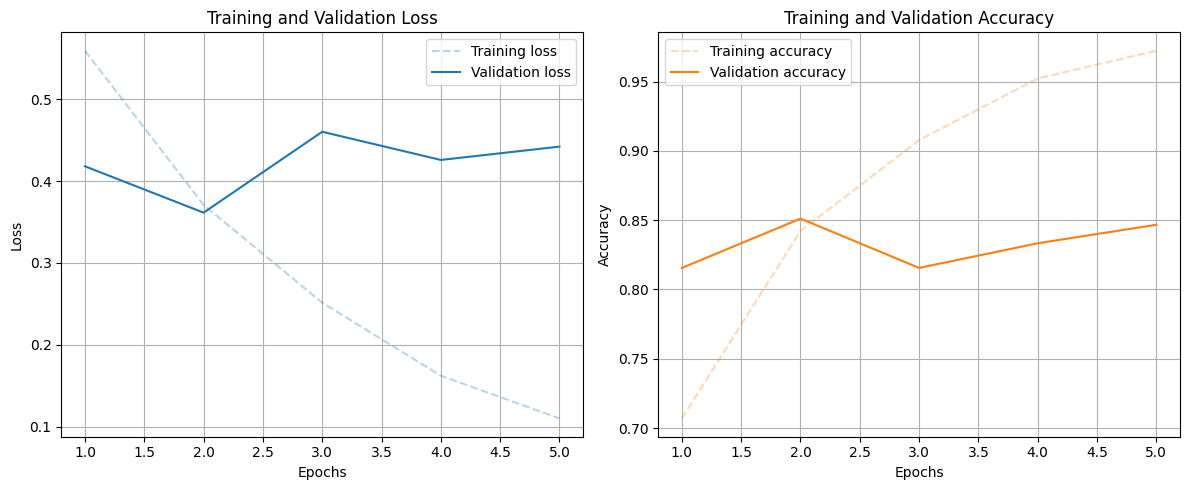

Predictions saved to submissions/s_BERT.csv
Deleted best_model/bm_fold_0.pt.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]


Starting training (RoBERTa):
Fold 0: Train size=1799, Val size=450


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/10: Train Loss: 0.5519, Train Acc: 0.7204 | Val Loss: 0.4099, Val Acc: 0.7956
  Validation loss improved from inf to 0.4099. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.3728, Train Acc: 0.8266 | Val Loss: 0.3848, Val Acc: 0.8289
  Validation loss improved from 0.4099 to 0.3848. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.2642, Train Acc: 0.8961 | Val Loss: 0.4401, Val Acc: 0.8156
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.1930, Train Acc: 0.9305 | Val Loss: 0.4483, Val Acc: 0.8200
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.1476, Train Acc: 0.9500 | Val Loss: 0.4296, Val Acc: 0.8467
  Validation loss did not improve for 3 epoch(s).
Early stopping triggered after 3 epochs without improvement.
Fold 0 Best Val Loss: 0.3848
There was only one fold.
Loaded best model weights from best_model/bm_fold_0.pt


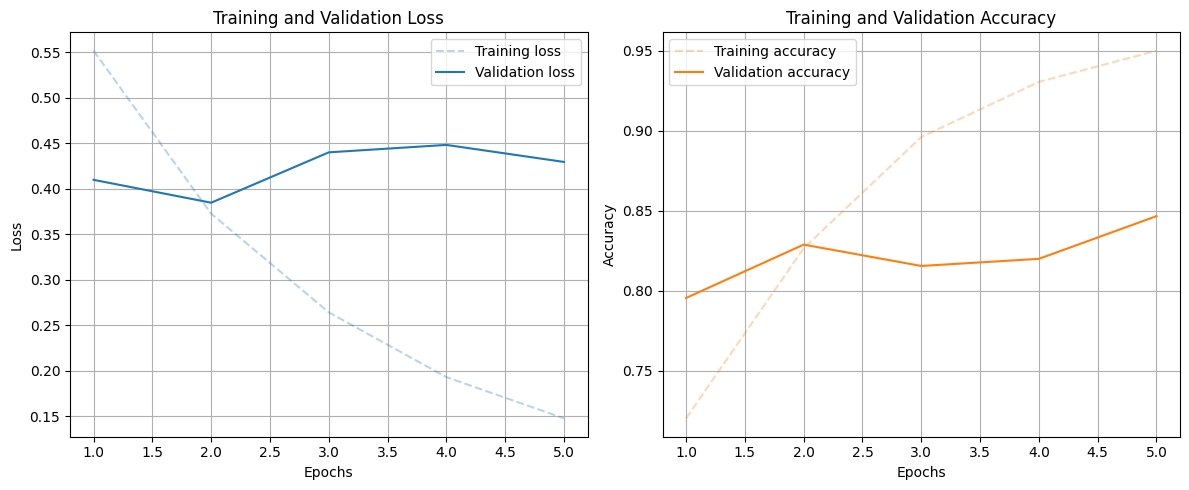

Predictions saved to submissions/s_RoBERTa.csv
Deleted best_model/bm_fold_0.pt.


tokenizer_config.json:   0%|          | 0.00/152 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Starting training (HateBERT):
Fold 0: Train size=1799, Val size=450


pytorch_model.bin:   0%|          | 0.00/669M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Epoch 1/10: Train Loss: 0.6060, Train Acc: 0.6954 | Val Loss: 0.5505, Val Acc: 0.7578
  Validation loss improved from inf to 0.5505. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.5278, Train Acc: 0.7593 | Val Loss: 0.4895, Val Acc: 0.7689
  Validation loss improved from 0.5505 to 0.4895. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.4860, Train Acc: 0.7799 | Val Loss: 0.4732, Val Acc: 0.7889
  Validation loss improved from 0.4895 to 0.4732. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.4499, Train Acc: 0.7943 | Val Loss: 0.4501, Val Acc: 0.7956
  Validation loss improved from 0.4732 to 0.4501. Model saved in best_model/bm_fold_0.pt.
Epoch 5/10: Train Loss: 0.4219, Train Acc: 0.8071 | Val Loss: 0.4726, Val Acc: 0.7733
  Validation loss did not improve for 1 epoch(s).
Epoch 6/10: Train Loss: 0.4042, Train Acc: 0.8227 | Val Loss: 0.5175, Val Acc: 0.7667
  Validation loss did not improve for 2 epoch(s).
Epoch 7/10: Train Loss: 0.3

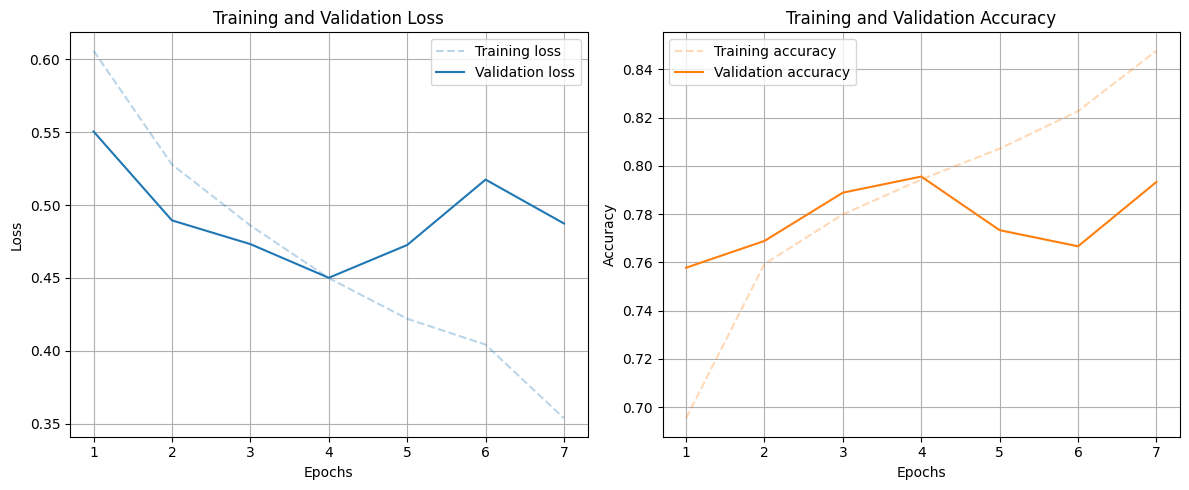

Predictions saved to submissions/s_HateBERT.csv
Deleted best_model/bm_fold_0.pt.


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 1/10: Train Loss: 0.6089, Train Acc: 0.6982 | Val Loss: 0.4526, Val Acc: 0.8200
  Validation loss improved from inf to 0.4526. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4259, Train Acc: 0.8310 | Val Loss: 0.4022, Val Acc: 0.8511
  Validation loss improved from 0.4526 to 0.4022. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3162, Train Acc: 0.8933 | Val Loss: 0.4038, Val Acc: 0.8489
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.2355, Train Acc: 0.9339 | Val Loss: 0.4413, Val Acc: 0.8244
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.2036, Train Acc: 0.9389 | Val Loss: 0.4341, Val Acc: 0.8444
  Validation loss did not improve for 3 epoch(s).
Early stopping triggered after 3 epochs without improvement.
Fold 0 Best Val Loss: 0.4022
There was only one fold.
Loaded best model weights from best_model/bm_fold_0.pt


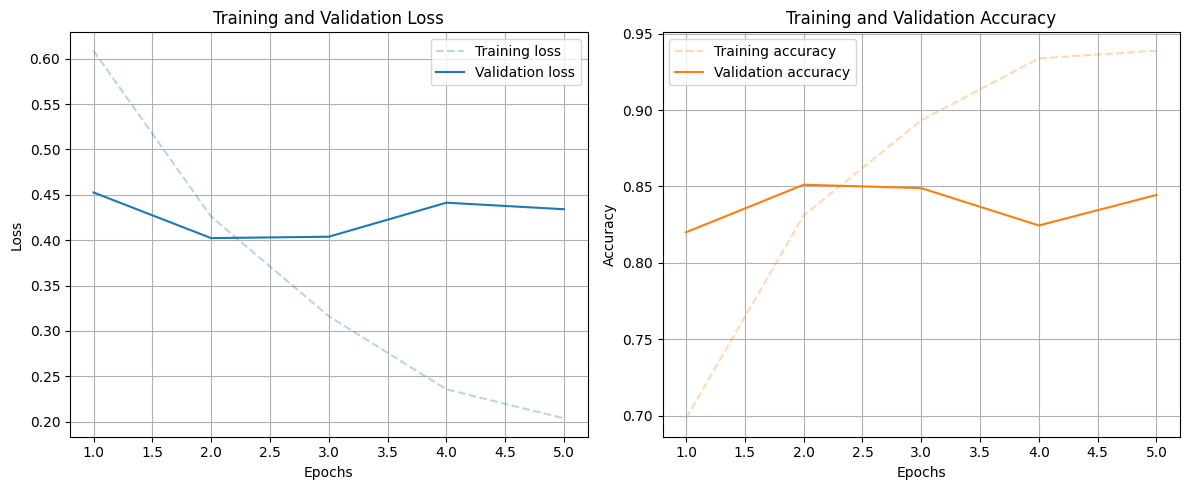

Predictions saved to submissions/s_BERTTweet.csv
Deleted best_model/bm_fold_0.pt.


In [ ]:
# First actual training part, let's gooo!
train('BERT', 'bert-base-uncased', appendix='BERT')
train('RoBERTa', 'roberta-base', appendix='RoBERTa')
train('HateBERT', 'Hate-speech-CNERG/dehatebert-mono-english', appendix='HateBERT')
train('BERTweet', 'vinai/bertweet-base', appendix='BERTTweet')


Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6002, Train Acc: 0.6898 | Val Loss: 0.4301, Val Acc: 0.8178
  Validation loss improved from inf to 0.4301. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4159, Train Acc: 0.8210 | Val Loss: 0.3767, Val Acc: 0.8511
  Validation loss improved from 0.4301 to 0.3767. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.2991, Train Acc: 0.8844 | Val Loss: 0.3687, Val Acc: 0.8533
  Validation loss improved from 0.3767 to 0.3687. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2094, Train Acc: 0.9311 | Val Loss: 0.5162, Val Acc: 0.8044
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.1432, Train Acc: 0.9578 | Val Loss: 0.3986, Val Acc: 0.8467
  Validation loss did not improve for 2 epoch(s).
Epoch 6/10: Train Loss: 0.0885, Train Acc: 0.9778 | Val Loss: 0.5337, Val Acc: 0.8067
  Validation loss did not improve for 3 epoch(s)

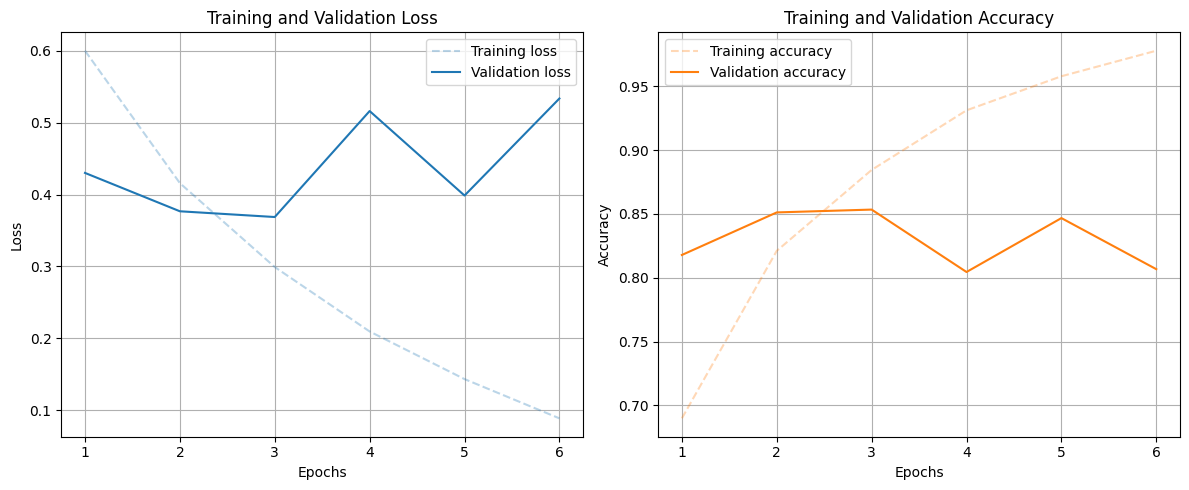

Predictions saved to submissions/s_minimalist.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6173, Train Acc: 0.7048 | Val Loss: 0.4681, Val Acc: 0.8111
  Validation loss improved from inf to 0.4681. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4464, Train Acc: 0.8177 | Val Loss: 0.4035, Val Acc: 0.8422
  Validation loss improved from 0.4681 to 0.4035. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3428, Train Acc: 0.8749 | Val Loss: 0.3989, Val Acc: 0.8422
  Validation loss improved from 0.4035 to 0.3989. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2645, Train Acc: 0.9150 | Val Loss: 0.3879, Val Acc: 0.8422
  Validation loss improved from 0.3989 to 0.3879. Model saved in best_model/bm_fold_0.pt.
Epoch 5/10: Train Loss: 0.2107, Train Acc: 0.9377 | Val Loss: 0.3663, Val Acc: 0.8622
  Validation loss improved from 0.3879 to 0.3663. Model saved

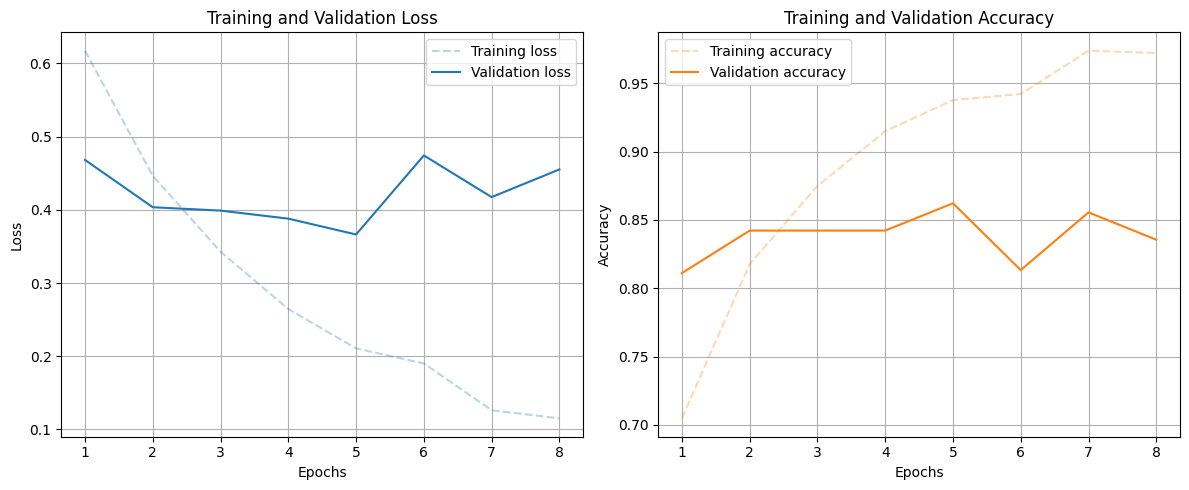

Predictions saved to submissions/s_bottleneck.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6015, Train Acc: 0.6876 | Val Loss: 0.4349, Val Acc: 0.8089
  Validation loss improved from inf to 0.4349. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4068, Train Acc: 0.8199 | Val Loss: 0.3927, Val Acc: 0.8356
  Validation loss improved from 0.4349 to 0.3927. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.2909, Train Acc: 0.8877 | Val Loss: 0.4096, Val Acc: 0.8400
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.1983, Train Acc: 0.9283 | Val Loss: 0.4725, Val Acc: 0.8333
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.1302, Train Acc: 0.9600 | Val Loss: 0.4540, Val Acc: 0.8511
  Validation loss did not improve for 3 epoch(s).
Early stopping triggered after 3 epochs without improvement.
Fold 0 Best Val Loss: 0.3927
T

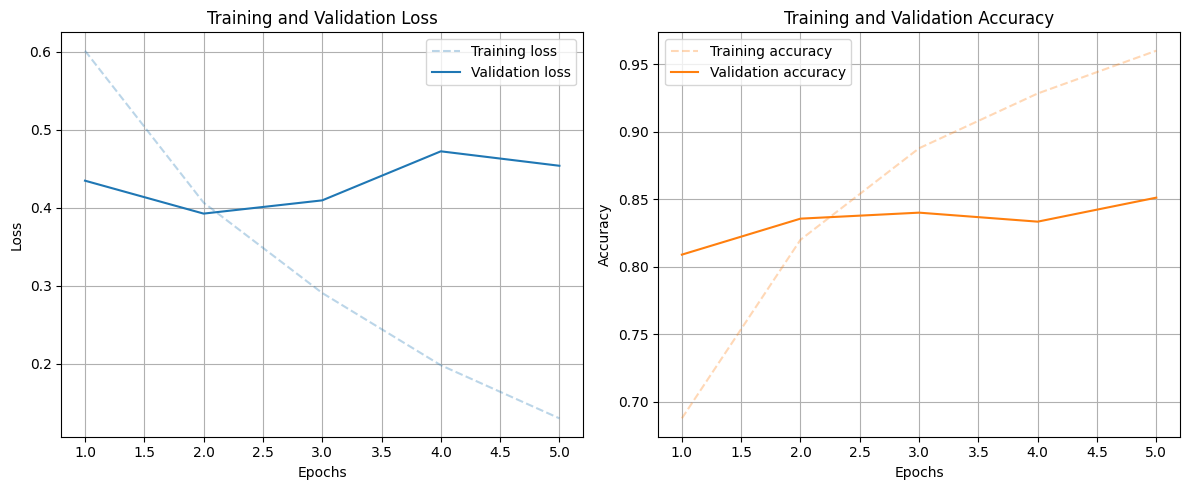

Predictions saved to submissions/s_projection_layer.csv
Deleted best_model/bm_fold_0.pt.


In [ ]:
minimalist_head = torch.nn.Sequential(
    torch.nn.Linear(768, 1),
    torch.nn.Sigmoid()
)

bottleneck_head = torch.nn.Sequential(
    torch.nn.Linear(768, 64),
    torch.nn.Tanh(),
    torch.nn.Linear(64, 1),
    torch.nn.Sigmoid()
)

projection_layer_head = torch.nn.Sequential(
    torch.nn.Linear(768, 768),
    torch.nn.Tanh(),
    torch.nn.Linear(768, 1),
    torch.nn.Sigmoid()
)

train('BERTweet', 'vinai/bertweet-base', head=minimalist_head, appendix='minimalist')
train('BERTweet', 'vinai/bertweet-base', head=bottleneck_head, appendix='bottleneck')
train('BERTweet', 'vinai/bertweet-base', head=projection_layer_head, appendix='projection_layer')


Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6089, Train Acc: 0.6982 | Val Loss: 0.4526, Val Acc: 0.8200
  Validation loss improved from inf to 0.4526. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4259, Train Acc: 0.8310 | Val Loss: 0.4022, Val Acc: 0.8511
  Validation loss improved from 0.4526 to 0.4022. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3162, Train Acc: 0.8933 | Val Loss: 0.4038, Val Acc: 0.8489
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.2355, Train Acc: 0.9339 | Val Loss: 0.4413, Val Acc: 0.8244
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.2036, Train Acc: 0.9389 | Val Loss: 0.4341, Val Acc: 0.8444
  Validation loss did not improve for 3 epoch(s).
Early stopping triggered after 3 epochs without improvement.
Fold 0 Best Val Loss: 0.4022
There was only one fold.
Loaded best model weights from best_model/bm_fold_0.pt


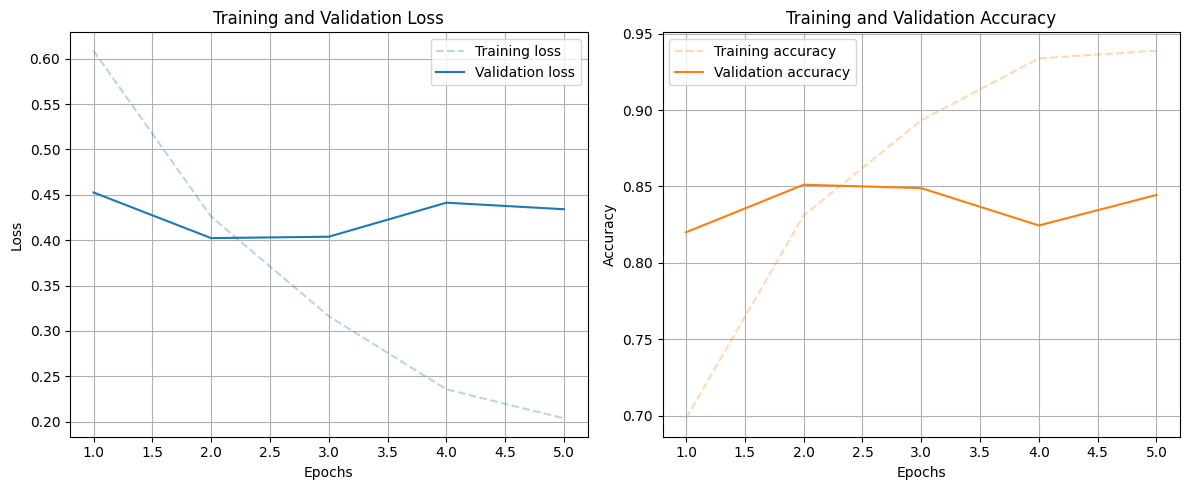

Predictions saved to submissions/s_cls_last.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.5821, Train Acc: 0.7148 | Val Loss: 0.4358, Val Acc: 0.8178
  Validation loss improved from inf to 0.4358. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4128, Train Acc: 0.8216 | Val Loss: 0.3884, Val Acc: 0.8356
  Validation loss improved from 0.4358 to 0.3884. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3176, Train Acc: 0.8805 | Val Loss: 0.3653, Val Acc: 0.8511
  Validation loss improved from 0.3884 to 0.3653. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2570, Train Acc: 0.9127 | Val Loss: 0.3996, Val Acc: 0.8378
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.2018, Train Acc: 0.9427 | Val Loss: 0.3585, Val Acc: 0.8644
  Validation loss improved from 0.3653 to 0.3585. Model saved in best_model/bm_fold_0.pt.
Epoch 6/10: T

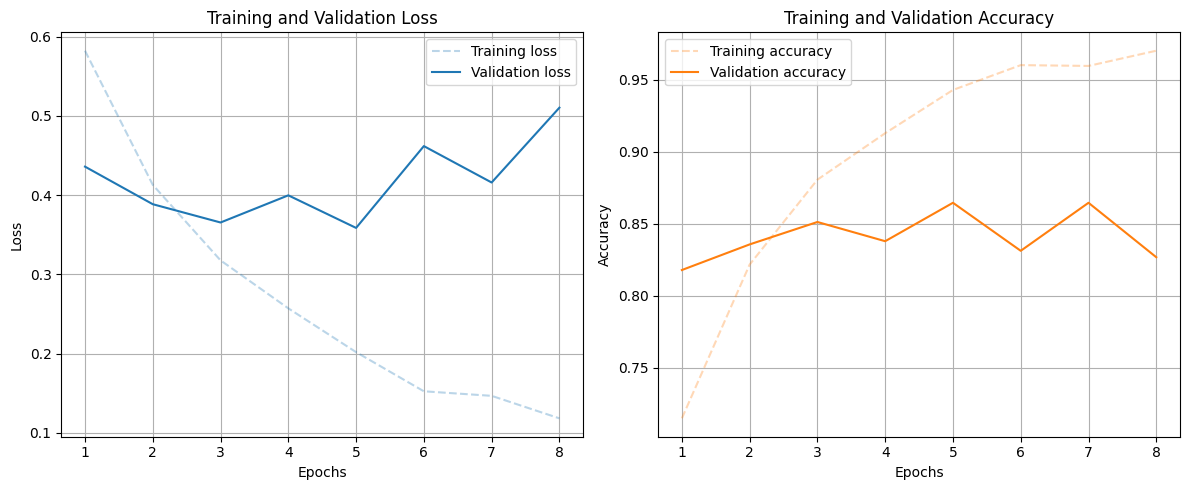

Predictions saved to submissions/s_mean_last.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6797, Train Acc: 0.5542 | Val Loss: 0.5949, Val Acc: 0.7333
  Validation loss improved from inf to 0.5949. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.5321, Train Acc: 0.7765 | Val Loss: 0.4198, Val Acc: 0.8111
  Validation loss improved from 0.5949 to 0.4198. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3842, Train Acc: 0.8371 | Val Loss: 0.3947, Val Acc: 0.8267
  Validation loss improved from 0.4198 to 0.3947. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.3087, Train Acc: 0.8766 | Val Loss: 0.3974, Val Acc: 0.8444
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.2300, Train Acc: 0.9211 | Val Loss: 0.3815, Val Acc: 0.8556
  Validation loss improved from 0.3947 to 0.3815. Model saved in best_model/bm_fold_0.pt.
Epoch 6/10: 

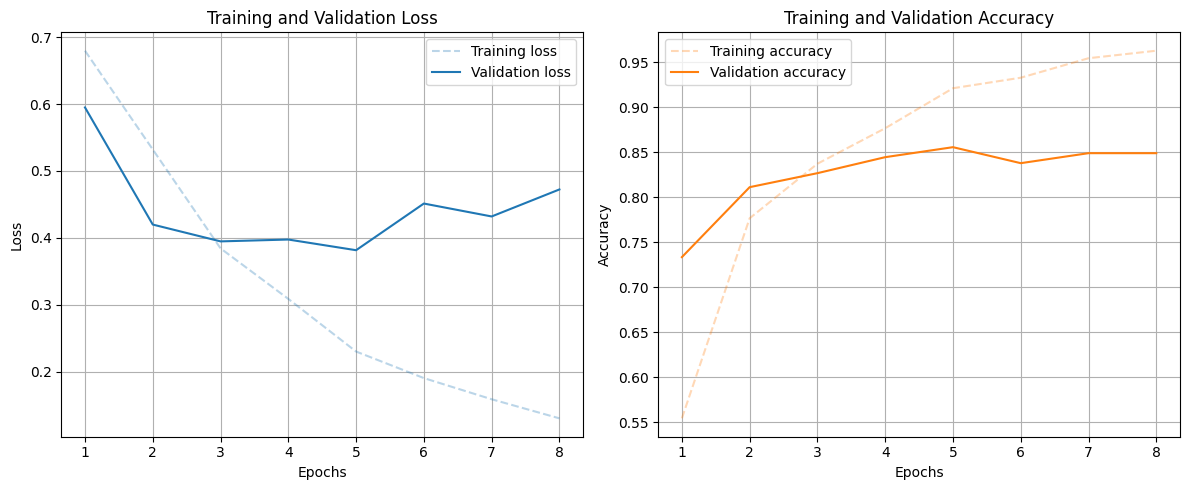

Predictions saved to submissions/s_cls_attn.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6004, Train Acc: 0.7009 | Val Loss: 0.4536, Val Acc: 0.8044
  Validation loss improved from inf to 0.4536. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4167, Train Acc: 0.8116 | Val Loss: 0.3863, Val Acc: 0.8289
  Validation loss improved from 0.4536 to 0.3863. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3164, Train Acc: 0.8744 | Val Loss: 0.3574, Val Acc: 0.8578
  Validation loss improved from 0.3863 to 0.3574. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2255, Train Acc: 0.9255 | Val Loss: 0.3654, Val Acc: 0.8600
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.1697, Train Acc: 0.9461 | Val Loss: 0.3687, Val Acc: 0.8622
  Validation loss did not improve for 2 epoch(s).
Epoch 6/10: Train Loss: 0.1343, Train Acc: 0.9578 | V

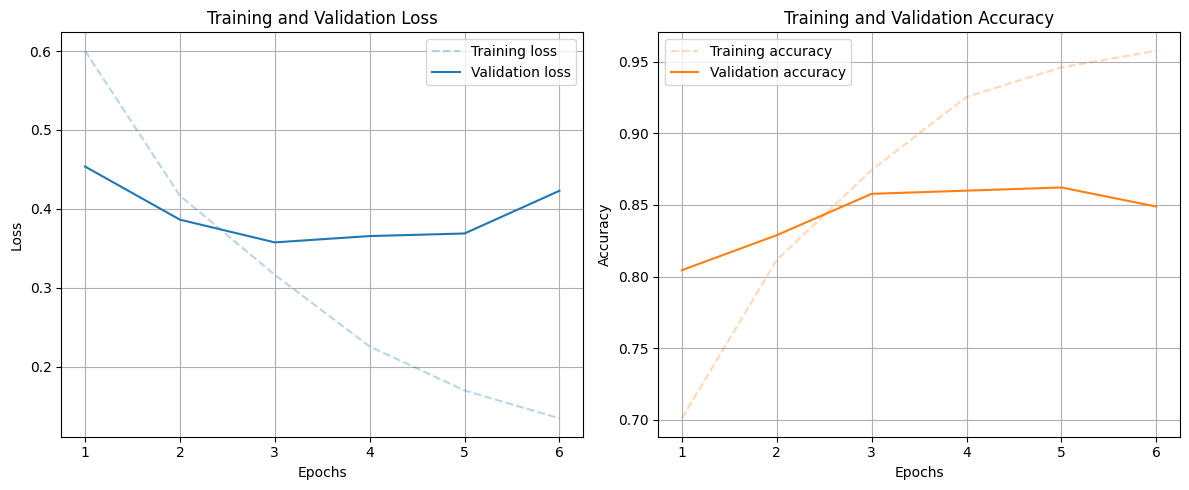

Predictions saved to submissions/s_mean_attn.csv
Deleted best_model/bm_fold_0.pt.


In [ ]:
train('BERTweet', 'vinai/bertweet-base',
      appendix='cls_last'
)

train('BERTweet', 'vinai/bertweet-base',
      token_pooling='mean',
      appendix='mean_last'
)

train('BERTweet', 'vinai/bertweet-base',
      layer_pooling='attn',
      layers_to_use=[9, 10, 11],
      appendix='cls_attn'
)

train('BERTweet', 'vinai/bertweet-base',
      token_pooling='mean',
      layer_pooling='attn',
      layers_to_use=[9, 10, 11],
      appendix='mean_attn'
)


Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6173, Train Acc: 0.7048 | Val Loss: 0.4681, Val Acc: 0.8111
  Validation loss improved from inf to 0.4681. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4464, Train Acc: 0.8177 | Val Loss: 0.4035, Val Acc: 0.8422
  Validation loss improved from 0.4681 to 0.4035. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3428, Train Acc: 0.8749 | Val Loss: 0.3989, Val Acc: 0.8422
  Validation loss improved from 0.4035 to 0.3989. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2645, Train Acc: 0.9150 | Val Loss: 0.3879, Val Acc: 0.8422
  Validation loss improved from 0.3989 to 0.3879. Model saved in best_model/bm_fold_0.pt.
Epoch 5/10: Train Loss: 0.2107, Train Acc: 0.9377 | Val Loss: 0.3663, Val Acc: 0.8622
  Validation loss improved from 0.3879 to 0.3663. Model saved in best_model/bm_fold_0.pt.
Epoch 6/10: Train Loss: 0.1901, Train Acc: 0.9422 | Va

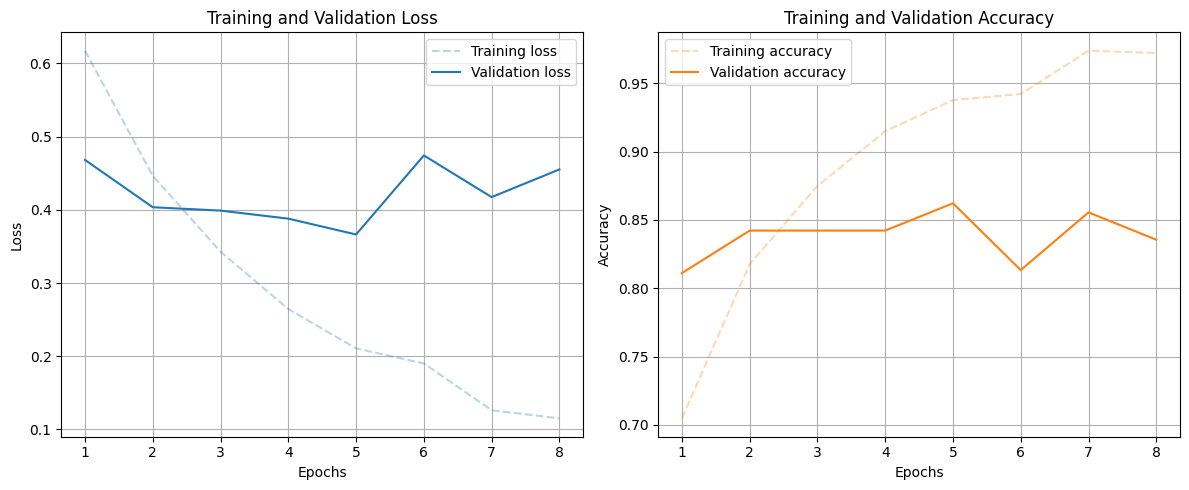

Predictions saved to submissions/s_0.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6218, Train Acc: 0.6737 | Val Loss: 0.4700, Val Acc: 0.8111
  Validation loss improved from inf to 0.4700. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4517, Train Acc: 0.8216 | Val Loss: 0.3926, Val Acc: 0.8378
  Validation loss improved from 0.4700 to 0.3926. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3404, Train Acc: 0.8777 | Val Loss: 0.3898, Val Acc: 0.8378
  Validation loss improved from 0.3926 to 0.3898. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2642, Train Acc: 0.9138 | Val Loss: 0.4688, Val Acc: 0.7978
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.2083, Train Acc: 0.9411 | Val Loss: 0.3847, Val Acc: 0.8556
  Validation loss improved from 0.3898 to 0.3847. Model saved in best_model/bm_fold_0.pt.
Epoch 6/10: Train Lo

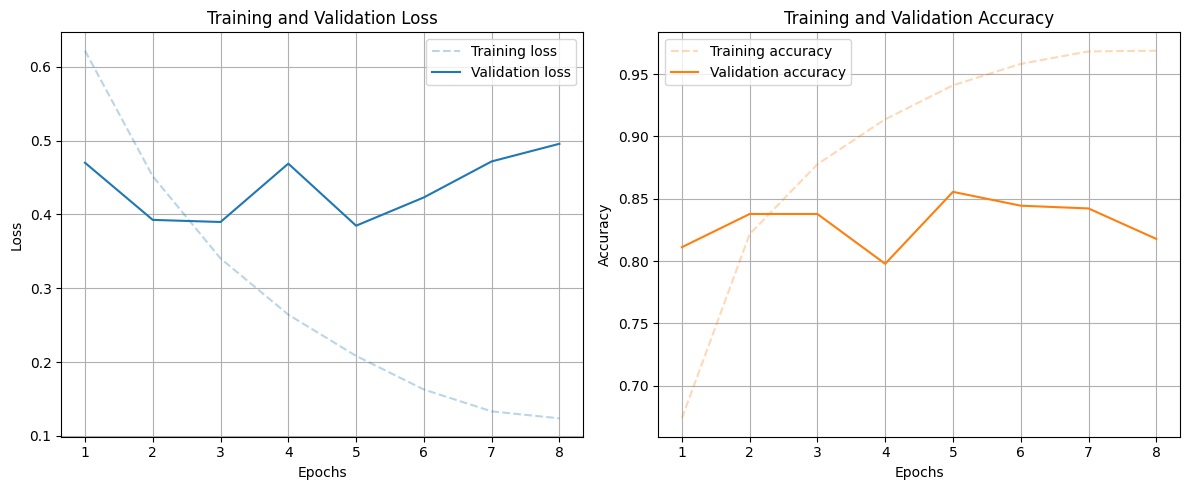

Predictions saved to submissions/s_2.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6298, Train Acc: 0.6709 | Val Loss: 0.4786, Val Acc: 0.8200
  Validation loss improved from inf to 0.4786. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4627, Train Acc: 0.8132 | Val Loss: 0.3897, Val Acc: 0.8400
  Validation loss improved from 0.4786 to 0.3897. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3485, Train Acc: 0.8738 | Val Loss: 0.3945, Val Acc: 0.8289
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.2769, Train Acc: 0.9111 | Val Loss: 0.4632, Val Acc: 0.8044
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.2211, Train Acc: 0.9372 | Val Loss: 0.3631, Val Acc: 0.8622
  Validation loss improved from 0.3897 to 0.3631. Model saved in best_model/bm_fold_0.pt.
Epoch 6/10: Train Loss: 0.1817, Train Acc: 0.9489 | Val Loss

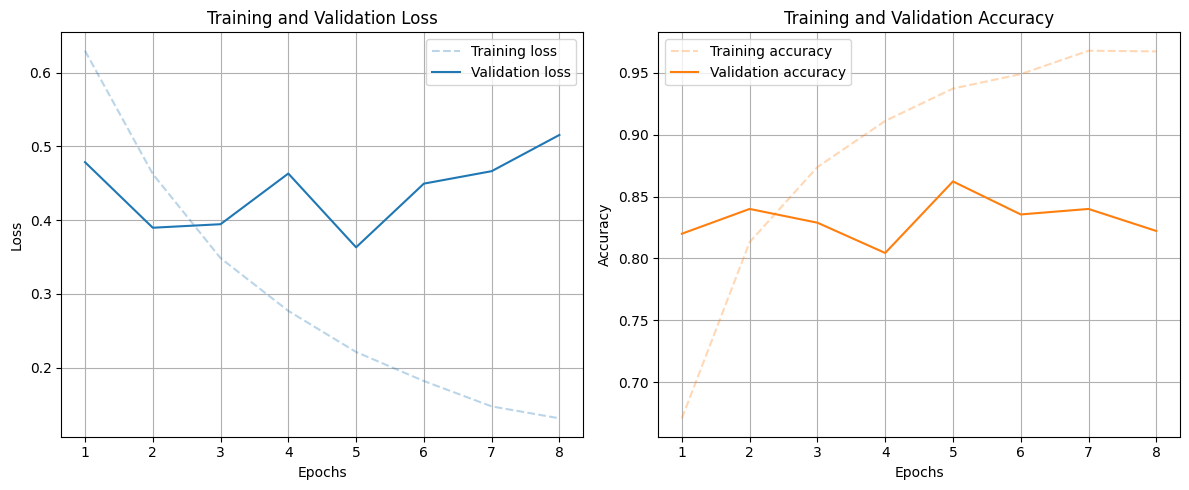

Predictions saved to submissions/s_4.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6385, Train Acc: 0.6593 | Val Loss: 0.4963, Val Acc: 0.8067
  Validation loss improved from inf to 0.4963. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4771, Train Acc: 0.8021 | Val Loss: 0.4103, Val Acc: 0.8244
  Validation loss improved from 0.4963 to 0.4103. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3657, Train Acc: 0.8694 | Val Loss: 0.3825, Val Acc: 0.8533
  Validation loss improved from 0.4103 to 0.3825. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2887, Train Acc: 0.9077 | Val Loss: 0.4602, Val Acc: 0.8000
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.2229, Train Acc: 0.9389 | Val Loss: 0.3668, Val Acc: 0.8533
  Validation loss improved from 0.3825 to 0.3668. Model saved in best_model/bm_fold_0.pt.
Epoch 6/10: Train Lo

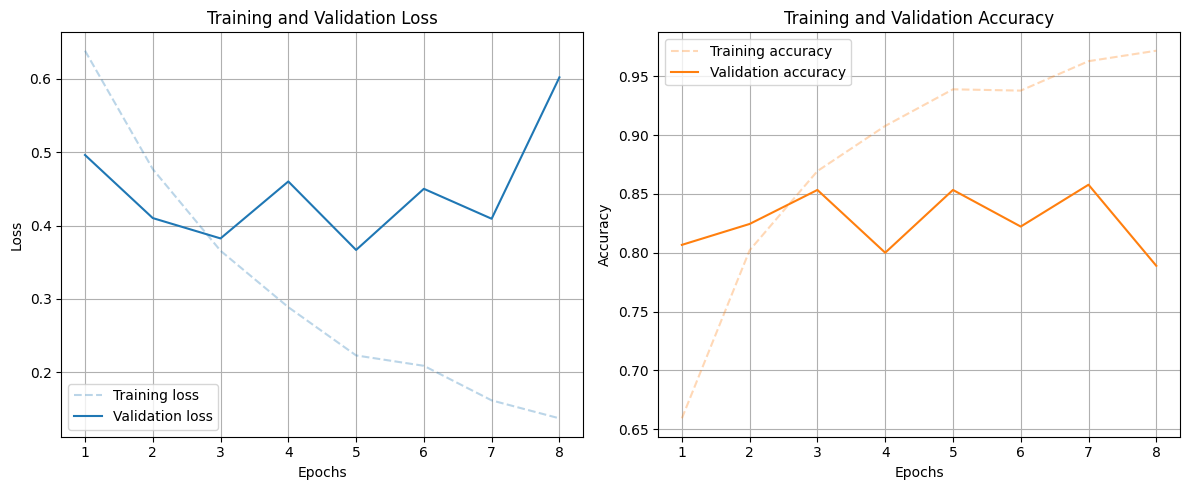

Predictions saved to submissions/s_5.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6469, Train Acc: 0.6531 | Val Loss: 0.5136, Val Acc: 0.8089
  Validation loss improved from inf to 0.5136. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4856, Train Acc: 0.7966 | Val Loss: 0.4084, Val Acc: 0.8378
  Validation loss improved from 0.5136 to 0.4084. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3706, Train Acc: 0.8710 | Val Loss: 0.3684, Val Acc: 0.8533
  Validation loss improved from 0.4084 to 0.3684. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.3001, Train Acc: 0.9022 | Val Loss: 0.4385, Val Acc: 0.8178
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.2375, Train Acc: 0.9305 | Val Loss: 0.3756, Val Acc: 0.8556
  Validation loss did not improve for 2 epoch(s).
Epoch 6/10: Train Loss: 0.1999, Train Acc: 0.9461 | Val Loss

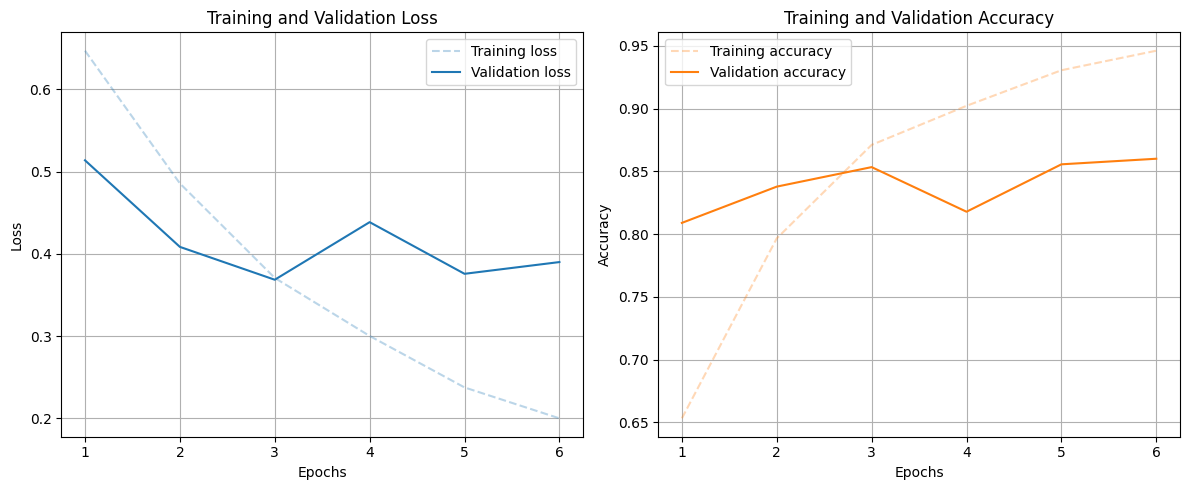

Predictions saved to submissions/s_6.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6695, Train Acc: 0.5981 | Val Loss: 0.5857, Val Acc: 0.7822
  Validation loss improved from inf to 0.5857. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.5365, Train Acc: 0.7827 | Val Loss: 0.4408, Val Acc: 0.8156
  Validation loss improved from 0.5857 to 0.4408. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.4356, Train Acc: 0.8382 | Val Loss: 0.4144, Val Acc: 0.8378
  Validation loss improved from 0.4408 to 0.4144. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.3705, Train Acc: 0.8733 | Val Loss: 0.3951, Val Acc: 0.8400
  Validation loss improved from 0.4144 to 0.3951. Model saved in best_model/bm_fold_0.pt.
Epoch 5/10: Train Loss: 0.3210, Train Acc: 0.9033 | Val Loss: 0.3953, Val Acc: 0.8467
  Validation loss did not improve for 1 epoch(s).
Epoch 6/10: Train Lo

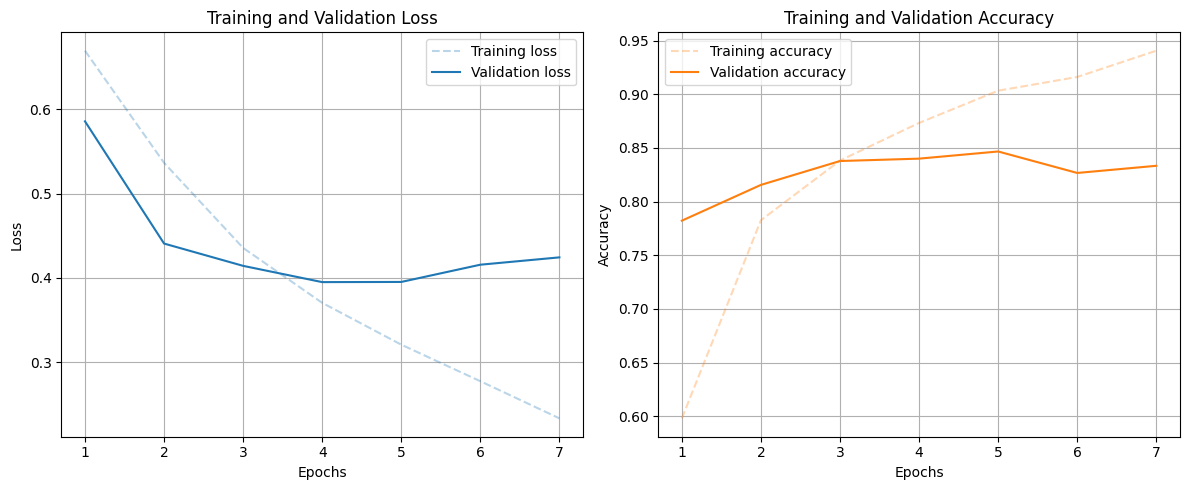

Predictions saved to submissions/s_8.csv
Deleted best_model/bm_fold_0.pt.


In [ ]:
def dropout_head(dropout_rate):
  return torch.nn.Sequential(
    torch.nn.Linear(768, 64),
    torch.nn.Tanh(),
    torch.nn.Dropout(dropout_rate),
    torch.nn.Linear(64, 1),
    torch.nn.Sigmoid()
)

for dropout_rate in[0.0, 0.2, 0.4, 0.5, 0.6, 0.8]:
  train(
      'BERTweet',
      'vinai/bertweet-base',
      head=dropout_head(dropout_rate),
      appendix=str(dropout_rate).split(".")[1]
  )

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 1/10: Train Loss: 0.6089, Train Acc: 0.6982 | Val Loss: 0.4526, Val Acc: 0.8200
  Validation loss improved from inf to 0.4526. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4259, Train Acc: 0.8310 | Val Loss: 0.4022, Val Acc: 0.8511
  Validation loss improved from 0.4526 to 0.4022. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3162, Train Acc: 0.8933 | Val Loss: 0.4038, Val Acc: 0.8489
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.2355, Train Acc: 0.9339 | Val Loss: 0.4413, Val Acc: 0.8244
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.2036, Train Acc: 0.9389 | Val Loss: 0.4341, Val Acc: 0.8444
  Validation loss did not improve for 3 epoch(s).
Early stopping triggered after 3 epochs without improvement.
Fold 0 Best Val Loss: 0.4022
There was only one fold.
Loaded best model weights from best_model/bm_fold_0.pt


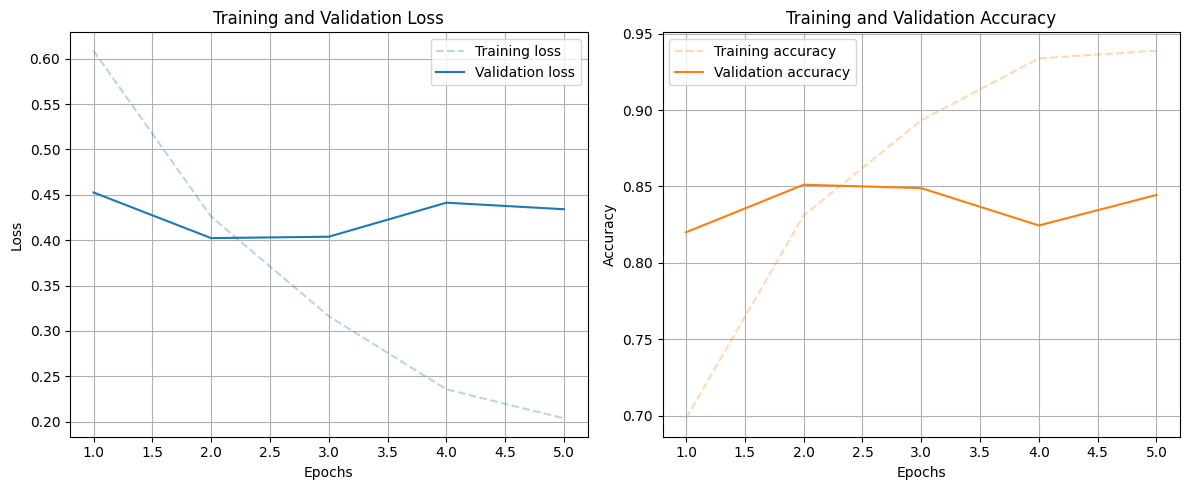

Predictions saved to submissions/s_global_learning_rate.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6778, Train Acc: 0.5959 | Val Loss: 0.6354, Val Acc: 0.7711
  Validation loss improved from inf to 0.6354. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.5928, Train Acc: 0.7376 | Val Loss: 0.4995, Val Acc: 0.7933
  Validation loss improved from 0.6354 to 0.4995. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.4766, Train Acc: 0.7804 | Val Loss: 0.4355, Val Acc: 0.8022
  Validation loss improved from 0.4995 to 0.4355. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.4263, Train Acc: 0.8060 | Val Loss: 0.4202, Val Acc: 0.8178
  Validation loss improved from 0.4355 to 0.4202. Model saved in best_model/bm_fold_0.pt.
Epoch 5/10: Train Loss: 0.3900, Train Acc: 0.8160 | Val Loss: 0.4150, Val Acc: 0.8200
  Validation loss improved from 0.4202 to 0.4150. M

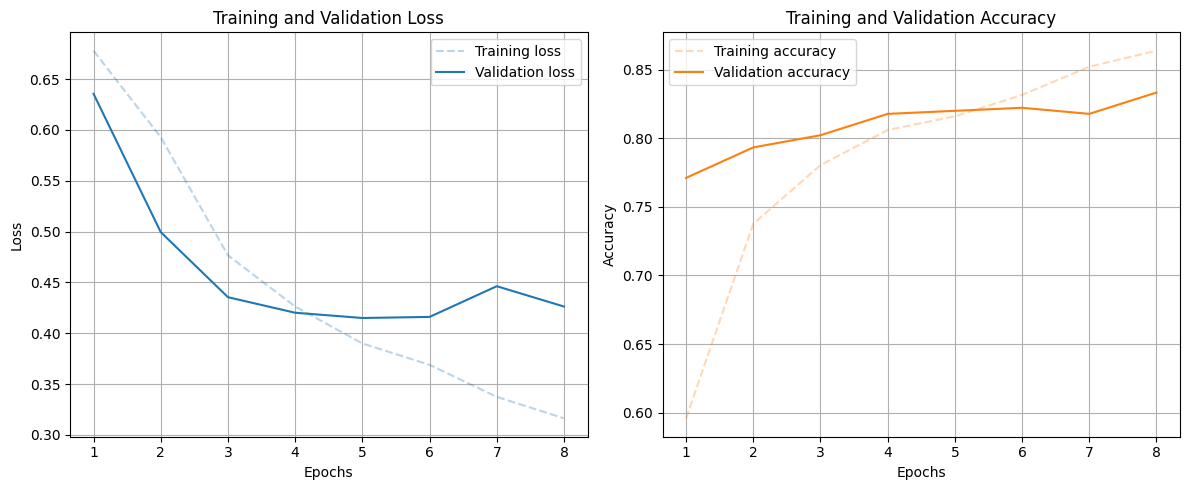

Predictions saved to submissions/s_seperate_learning_rate.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
  [LR Check] BERT: 0.00e+00 | Head: 1.00e-04
Epoch 1/10: Train Loss: 0.6827, Train Acc: 0.5787 | Val Loss: 0.6531, Val Acc: 0.7200
  Validation loss improved from inf to 0.6531. Model saved in best_model/bm_fold_0.pt.
  [LR Check] BERT: 1.00e-06 | Head: 1.00e-04
Epoch 2/10: Train Loss: 0.6171, Train Acc: 0.7221 | Val Loss: 0.5302, Val Acc: 0.7933
  Validation loss improved from 0.6531 to 0.5302. Model saved in best_model/bm_fold_0.pt.
  [LR Check] BERT: 9.44e-07 | Head: 9.44e-05
Epoch 3/10: Train Loss: 0.5005, Train Acc: 0.7732 | Val Loss: 0.4460, Val Acc: 0.8089
  Validation loss improved from 0.5302 to 0.4460. Model saved in best_model/bm_fold_0.pt.
  [LR Check] BERT: 8.89e-07 | Head: 8.89e-05
Epoch 4/10: Train Loss: 0.4436, Train Acc: 0.7932 | Val Loss: 0.4268, Val Acc: 0.8089
  Validation loss improved from 0.4460 to 0.4

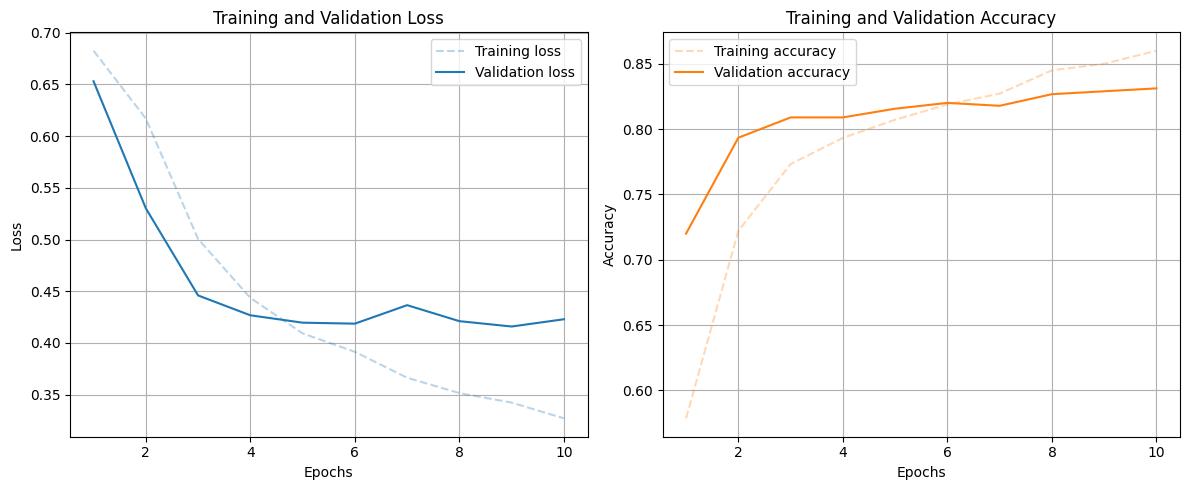

Predictions saved to submissions/s_warmup_and_decay.csv
Deleted best_model/bm_fold_0.pt.


In [ ]:
train(
    'BERTweet',
    'vinai/bertweet-base',
    appendix='global_learning_rate',
    learning_rate=1e-5
)

train(
    'BERTweet',
    'vinai/bertweet-base',
    appendix='seperate_learning_rate',
    learning_rate_bert=1e-6,
    learning_rate_head=1e-4
)

train(
    'BERTweet',
    'vinai/bertweet-base',
    appendix='warmup_and_decay',
    learning_rate_bert=1e-6,
    learning_rate_head=1e-4,
    warmup_and_decay=True
)


Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6089, Train Acc: 0.6982 | Val Loss: 0.4526, Val Acc: 0.8200
  Validation loss improved from inf to 0.4526. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4259, Train Acc: 0.8310 | Val Loss: 0.4022, Val Acc: 0.8511
  Validation loss improved from 0.4526 to 0.4022. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3162, Train Acc: 0.8933 | Val Loss: 0.4038, Val Acc: 0.8489
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.2355, Train Acc: 0.9339 | Val Loss: 0.4413, Val Acc: 0.8244
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.2036, Train Acc: 0.9389 | Val Loss: 0.4341, Val Acc: 0.8444
  Validation loss did not improve for 3 epoch(s).
Early stopping triggered after 3 epochs without improvement.
Fold 0 Best Val Loss: 0.4022
There was only one fold.
Loaded best model weights from best_model/bm_fold_0.pt


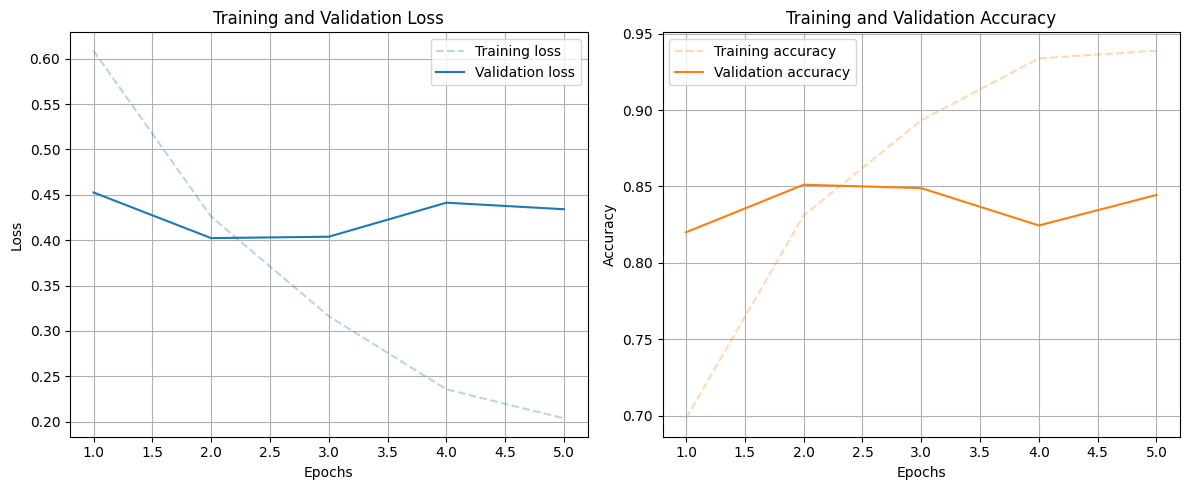

Predictions saved to submissions/s_not_augmented.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=3540, Val size=885
Epoch 1/10: Train Loss: 0.5335, Train Acc: 0.7506 | Val Loss: 0.3928, Val Acc: 0.8407
  Validation loss improved from inf to 0.3928. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.3606, Train Acc: 0.8633 | Val Loss: 0.3867, Val Acc: 0.8384
  Validation loss improved from 0.3928 to 0.3867. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.2568, Train Acc: 0.9144 | Val Loss: 0.2803, Val Acc: 0.8949
  Validation loss improved from 0.3867 to 0.2803. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.1790, Train Acc: 0.9489 | Val Loss: 0.2837, Val Acc: 0.8927
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.1426, Train Acc: 0.9627 | Val Loss: 0.2501, Val Acc: 0.9130
  Validation loss improved from 0.2803 to 0.2501. Model saved in best_model/bm_fold_0.pt.
Epoch 6/

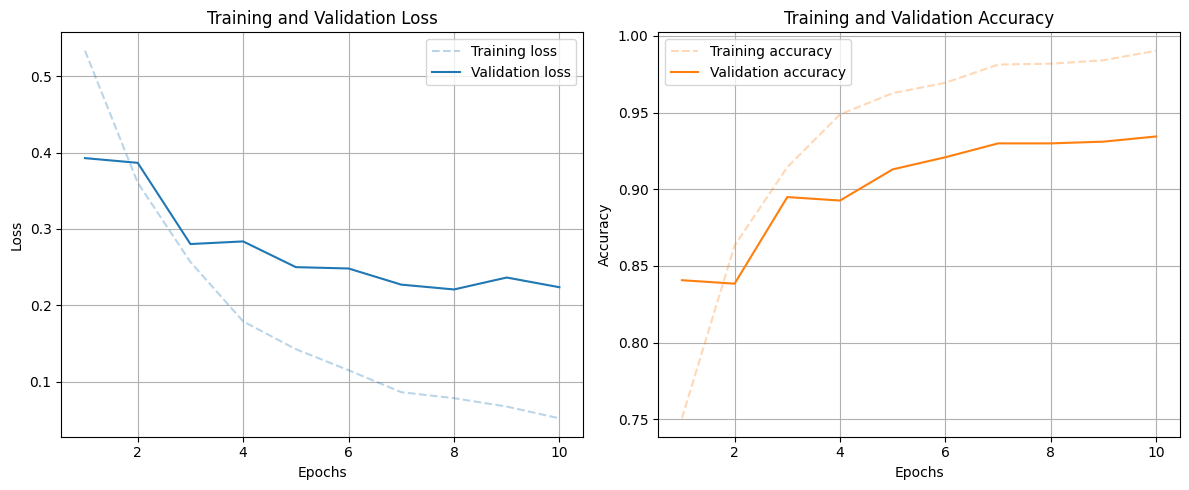

Predictions saved to submissions/s_backtr.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=2037, Val size=510
Epoch 1/10: Train Loss: 0.5974, Train Acc: 0.6912 | Val Loss: 0.4634, Val Acc: 0.8000
  Validation loss improved from inf to 0.4634. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4086, Train Acc: 0.8419 | Val Loss: 0.3983, Val Acc: 0.8412
  Validation loss improved from 0.4634 to 0.3983. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3135, Train Acc: 0.8910 | Val Loss: 0.4005, Val Acc: 0.8353
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.2454, Train Acc: 0.9224 | Val Loss: 0.3592, Val Acc: 0.8627
  Validation loss improved from 0.3983 to 0.3592. Model saved in best_model/bm_fold_0.pt.
Epoch 5/10: Train Loss: 0.2056, Train Acc: 0.9381 | Val Loss: 0.4184, Val Acc: 0.8412
  Validation loss did not improve for 1 epoch(s).
Epoch 6/10: Train Loss: 0.1592, Train Acc: 0.9568 | Val

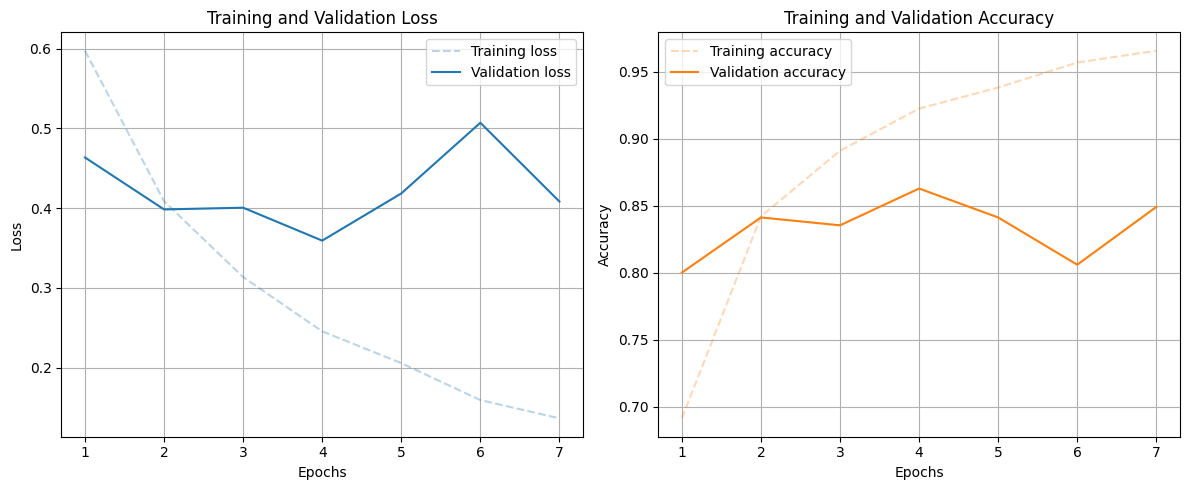

Predictions saved to submissions/s_ner.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=2644, Val size=661
Epoch 1/10: Train Loss: 0.6659, Train Acc: 0.5991 | Val Loss: 0.6297, Val Acc: 0.6021
  Validation loss improved from inf to 0.6297. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.5358, Train Acc: 0.7394 | Val Loss: 0.4266, Val Acc: 0.8185
  Validation loss improved from 0.6297 to 0.4266. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3841, Train Acc: 0.8464 | Val Loss: 0.3525, Val Acc: 0.8533
  Validation loss improved from 0.4266 to 0.3525. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2835, Train Acc: 0.8975 | Val Loss: 0.3493, Val Acc: 0.8654
  Validation loss improved from 0.3525 to 0.3493. Model saved in best_model/bm_fold_0.pt.
Epoch 5/10: Train Loss: 0.2158, Train Acc: 0.9300 | Val Loss: 0.3631, Val Acc: 0.8548
  Validation loss did not improve for 1 epoch(s).
Epoch 6/10: Train 

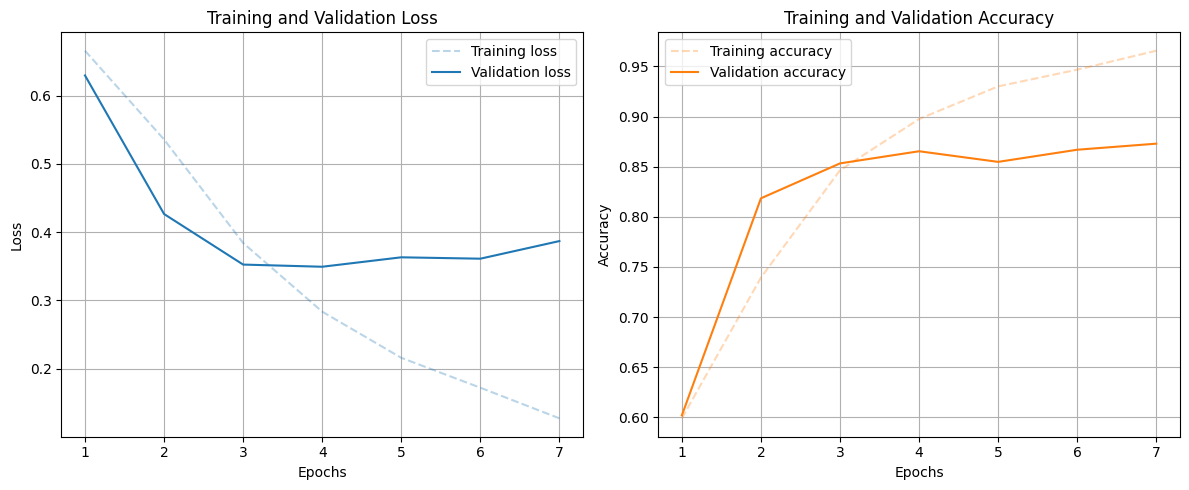

Predictions saved to submissions/s_adv_swap.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=2646, Val size=662
Epoch 1/10: Train Loss: 0.6621, Train Acc: 0.5971 | Val Loss: 0.5670, Val Acc: 0.7372
  Validation loss improved from inf to 0.5670. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4595, Train Acc: 0.8054 | Val Loss: 0.3785, Val Acc: 0.8263
  Validation loss improved from 0.5670 to 0.3785. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3231, Train Acc: 0.8813 | Val Loss: 0.3580, Val Acc: 0.8444
  Validation loss improved from 0.3785 to 0.3580. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2398, Train Acc: 0.9195 | Val Loss: 0.4041, Val Acc: 0.8338
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.1833, Train Acc: 0.9456 | Val Loss: 0.3801, Val Acc: 0.8595
  Validation loss did not improve for 2 epoch(s).
Epoch 6/10: Train Loss: 0.1441, Train Acc: 0.9607 | V

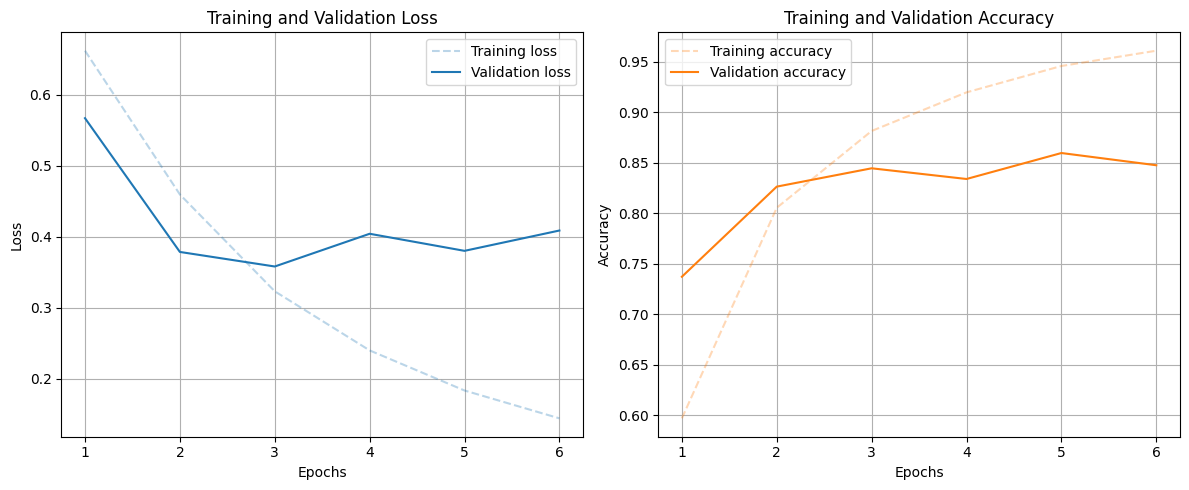

Predictions saved to submissions/s_adv_swap_test.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=5470, Val size=1368
Epoch 1/10: Train Loss: 0.5852, Train Acc: 0.6878 | Val Loss: 0.4471, Val Acc: 0.8085
  Validation loss improved from inf to 0.4471. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.3390, Train Acc: 0.8713 | Val Loss: 0.3203, Val Acc: 0.8794
  Validation loss improved from 0.4471 to 0.3203. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.2366, Train Acc: 0.9229 | Val Loss: 0.2963, Val Acc: 0.8823
  Validation loss improved from 0.3203 to 0.2963. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.1624, Train Acc: 0.9517 | Val Loss: 0.2668, Val Acc: 0.9072
  Validation loss improved from 0.2963 to 0.2668. Model saved in best_model/bm_fold_0.pt.
Epoch 5/10: Train Loss: 0.1230, Train Acc: 0.9669 | Val Loss: 0.2933, Val Acc: 0.8969
  Validation loss did not improve for 1 epoch(s).
Epoch 6

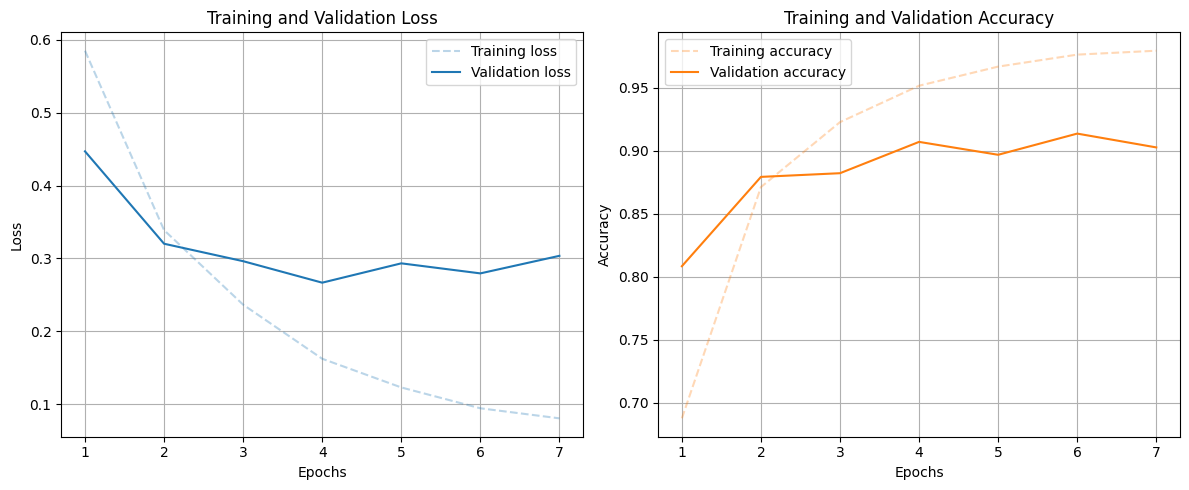

Predictions saved to submissions/s_augment_use_all.csv
Deleted best_model/bm_fold_0.pt.


In [ ]:
try:
    train('BERTweet', 'vinai/bertweet-base', appendix='not_augmented')

    load_csv_and_augment(use_aug=['backtr'])
    train('BERTweet', 'vinai/bertweet-base', appendix='backtr')

    load_csv_and_augment(use_aug=['ner'])
    train('BERTweet', 'vinai/bertweet-base', appendix='ner')

    load_csv_and_augment(use_aug=['adv_swap'])
    train('BERTweet', 'vinai/bertweet-base', appendix='adv_swap')

    load_csv_and_augment(use_aug=['adv_swap_test'])
    train('BERTweet', 'vinai/bertweet-base', appendix='adv_swap_test')

    load_csv_and_augment(use_aug=['backtr', 'ner', 'adv_swap', 'adv_swap_test'])
    train('BERTweet', 'vinai/bertweet-base', appendix='augment_use_all')
except:
    pass

# reset
load_csv_and_augment(use_aug=[])


Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6089, Train Acc: 0.6982 | Val Loss: 0.4526, Val Acc: 0.8200
  Validation loss improved from inf to 0.4526. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4259, Train Acc: 0.8310 | Val Loss: 0.4022, Val Acc: 0.8511
  Validation loss improved from 0.4526 to 0.4022. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3162, Train Acc: 0.8933 | Val Loss: 0.4038, Val Acc: 0.8489
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.2355, Train Acc: 0.9339 | Val Loss: 0.4413, Val Acc: 0.8244
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.2036, Train Acc: 0.9389 | Val Loss: 0.4341, Val Acc: 0.8444
  Validation loss did not improve for 3 epoch(s).
Early stopping triggered after 3 epochs without improvement.
Fold 0 Best Val Loss: 0.4022
There was only one fold.
Loaded best model weights from best_model/bm_fold_0.pt


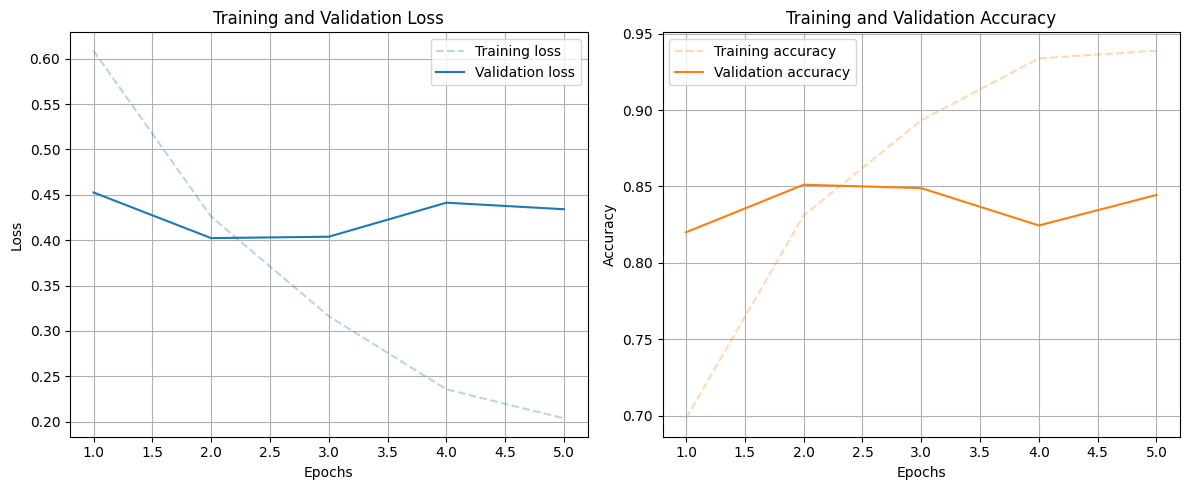

Predictions saved to submissions/s_1_fold.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6083, Train Acc: 0.7071 | Val Loss: 0.4766, Val Acc: 0.7867
  Validation loss improved from inf to 0.4766. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4157, Train Acc: 0.8332 | Val Loss: 0.4159, Val Acc: 0.8133
  Validation loss improved from 0.4766 to 0.4159. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3223, Train Acc: 0.8855 | Val Loss: 0.4057, Val Acc: 0.8133
  Validation loss improved from 0.4159 to 0.4057. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2424, Train Acc: 0.9250 | Val Loss: 0.4140, Val Acc: 0.8267
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.1909, Train Acc: 0.9444 | Val Loss: 0.4523, Val Acc: 0.8178
  Validation loss did not improve for 2 epoch(s).
Epoch 6/10: Train Loss: 0.1579, Train Acc: 0.9600 | Val

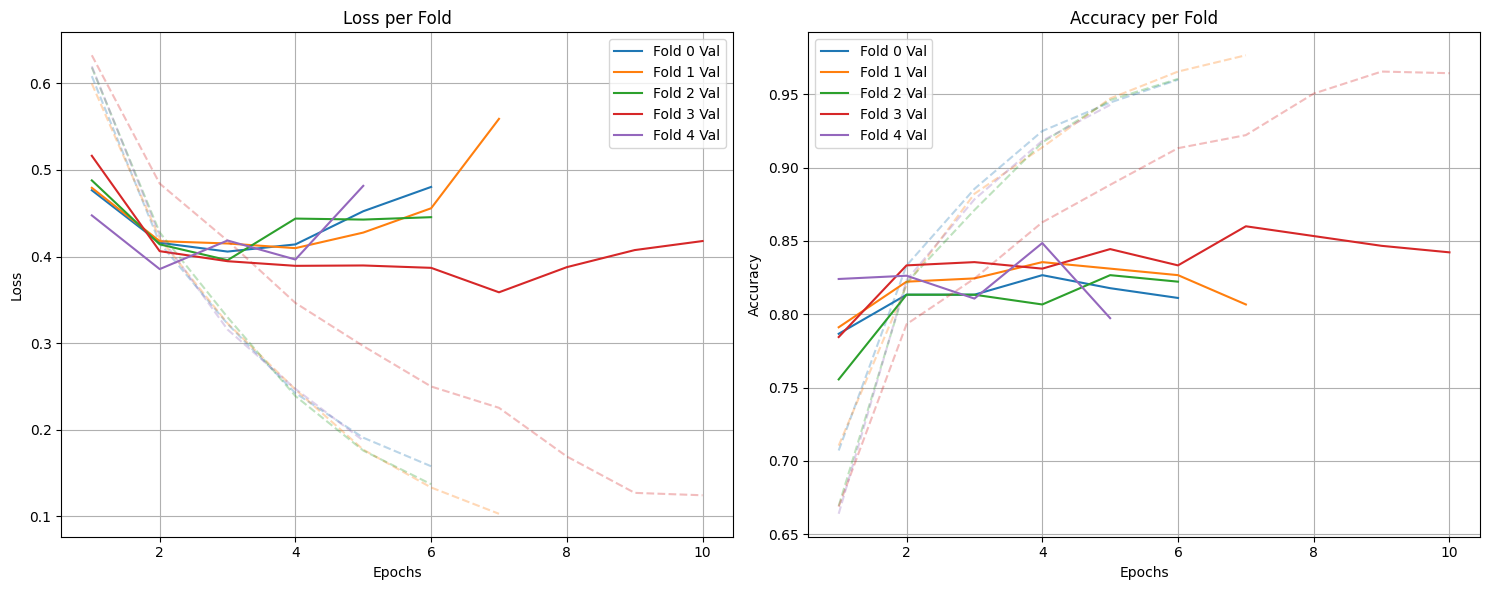

Starting Ensemble Inference for 5 folds...
 -> Loading weights from: best_model/bm_fold_0.pt
 -> Loading weights from: best_model/bm_fold_1.pt
 -> Loading weights from: best_model/bm_fold_2.pt
 -> Loading weights from: best_model/bm_fold_3.pt
 -> Loading weights from: best_model/bm_fold_4.pt
Ensemble predictions saved to submissions/s_5_folds.csv
Deleted best_model/bm_fold_0.pt.
Deleted best_model/bm_fold_1.pt.
Deleted best_model/bm_fold_2.pt.
Deleted best_model/bm_fold_3.pt.
Deleted best_model/bm_fold_4.pt.


In [ ]:
train('BERTweet', 'vinai/bertweet-base', appendix='1_fold')

train('BERTweet', 'vinai/bertweet-base', appendix='5_folds', n_splits=5)


Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6089, Train Acc: 0.6982 | Val Loss: 0.4526, Val Acc: 0.8200
  Validation loss improved from inf to 0.4526. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4259, Train Acc: 0.8310 | Val Loss: 0.4022, Val Acc: 0.8511
  Validation loss improved from 0.4526 to 0.4022. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3162, Train Acc: 0.8933 | Val Loss: 0.4038, Val Acc: 0.8489
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.2355, Train Acc: 0.9339 | Val Loss: 0.4413, Val Acc: 0.8244
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.2036, Train Acc: 0.9389 | Val Loss: 0.4341, Val Acc: 0.8444
  Validation loss did not improve for 3 epoch(s).
Early stopping triggered after 3 epochs without improvement.
Fold 0 Best Val Loss: 0.4022
There was only one fold.
Loaded best model weights from best_model/bm_fold_0.pt


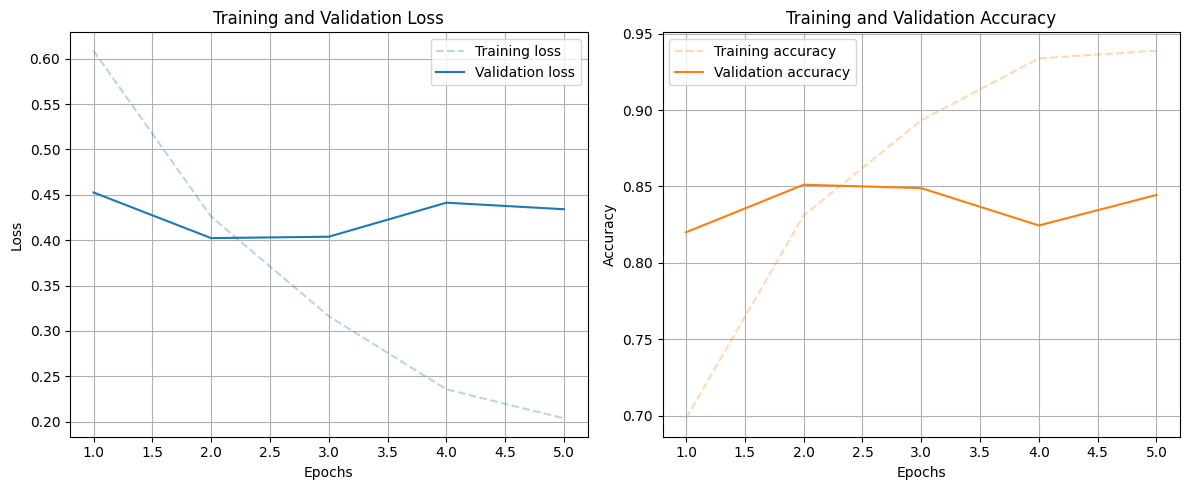

Predictions saved to submissions/s_no_weight.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.5453, Train Acc: 0.6559 | Val Loss: 0.4080, Val Acc: 0.8133
  Validation loss improved from inf to 0.4080. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.3900, Train Acc: 0.8166 | Val Loss: 0.3554, Val Acc: 0.8444
  Validation loss improved from 0.4080 to 0.3554. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.2975, Train Acc: 0.8794 | Val Loss: 0.3491, Val Acc: 0.8511
  Validation loss improved from 0.3554 to 0.3491. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.2314, Train Acc: 0.9172 | Val Loss: 0.3903, Val Acc: 0.8200
  Validation loss did not improve for 1 epoch(s).
Epoch 5/10: Train Loss: 0.1798, Train Acc: 0.9422 | Val Loss: 0.3515, Val Acc: 0.8356
  Validation loss did not improve for 2 epoch(s).
Epoch 6/10: Train Loss: 0.1443, Train Acc: 0.9550 | 

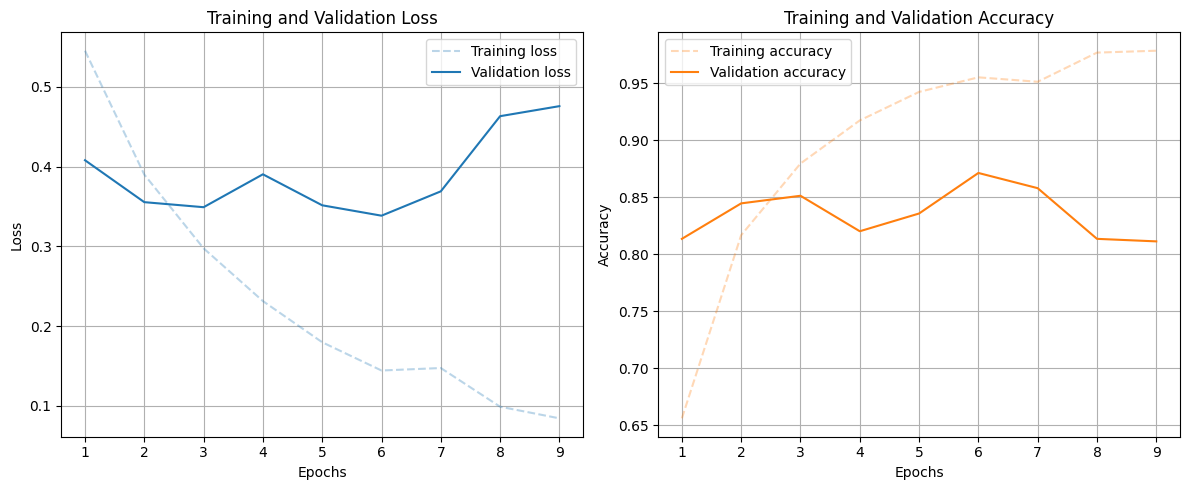

Predictions saved to submissions/s_weight_non_extr_more.csv
Deleted best_model/bm_fold_0.pt.

Starting training (BERTweet):
Fold 0: Train size=1799, Val size=450
Epoch 1/10: Train Loss: 0.6666, Train Acc: 0.6748 | Val Loss: 0.4939, Val Acc: 0.8156
  Validation loss improved from inf to 0.4939. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.4638, Train Acc: 0.8277 | Val Loss: 0.4340, Val Acc: 0.8378
  Validation loss improved from 0.4939 to 0.4340. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.3381, Train Acc: 0.8894 | Val Loss: 0.4382, Val Acc: 0.8333
  Validation loss did not improve for 1 epoch(s).
Epoch 4/10: Train Loss: 0.2668, Train Acc: 0.9188 | Val Loss: 0.5195, Val Acc: 0.8178
  Validation loss did not improve for 2 epoch(s).
Epoch 5/10: Train Loss: 0.2225, Train Acc: 0.9400 | Val Loss: 0.4196, Val Acc: 0.8467
  Validation loss improved from 0.4340 to 0.4196. Model saved in best_model/bm_fold_0.pt.
Epoch 6/10: Train Loss: 0.1852, Train Acc

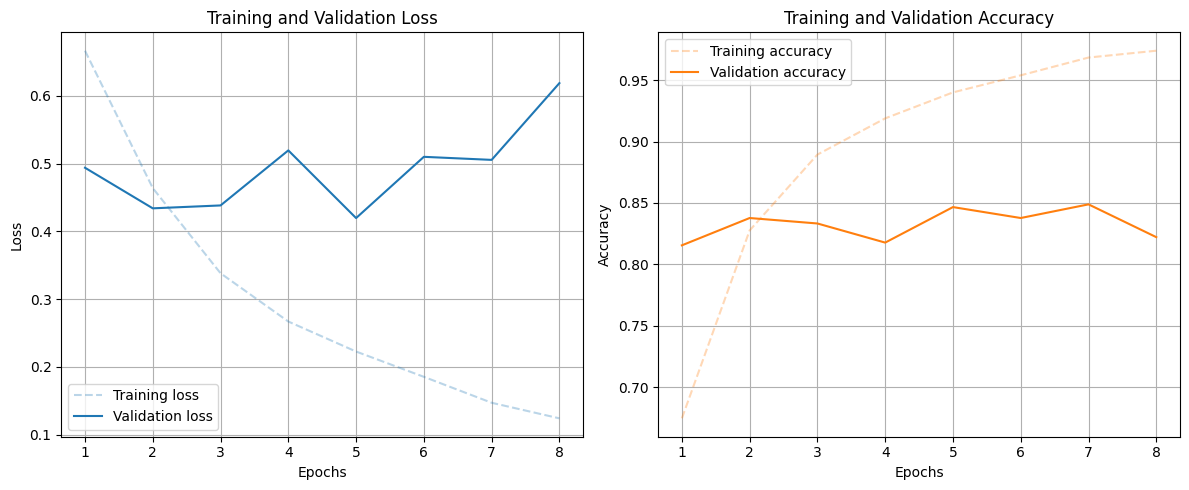

Predictions saved to submissions/s_weight_extr_more.csv
Deleted best_model/bm_fold_0.pt.


In [ ]:
train('BERTweet', 'vinai/bertweet-base', appendix='no_weight')

train('BERTweet', 'vinai/bertweet-base', appendix='weight_non_extr_more', pos_weight=0.8)

train('BERTweet', 'vinai/bertweet-base', appendix='weight_extr_more', pos_weight=1.2)

# Summary

### Finished

*(I made it kind of logbook style so we wouldn't forget what to say in the report, and show our learning path.)*

- Create MVP
  - GPU check
  - downloading files automatically to account for Google CoLAB non-persistent files
  - loading BERT
  - combined architecture of BERT + some head
    - bug solved using bridge (environments like Colab install Keras 3 alongside TensorFlow 2.x, leading to an internal mismatch)
  - label transformations to/from binary
  - calculating accuracy
    - splitting training data into train + test
- Create plots for loss and accuracy
- Create an export function for Kaggle submissions
- Unfreezing BERT (big accuracy boost)
- Try different BERT models
  - Generalizing code
  - Bugfix in using Automodel
- Try different heads
- Save best model (early stopping, prevent overfitting)
  - Bug (validation_acc 0 on using callbacks) -> apparently the imports need to have this exact order (transformers?)
  - Bug (Use tensorflow keras for correct version, see earlier similar bugfix)
  - Switched to PyTorch + Keras, no more TensorFlow
- Different learning rates for BERT and head
  - Keras doesn't allow this with it's compile and fit functions
  - Switched to pure PyTorch, no more Keras
  - Put on hold (I got tired hahah)
- Switched to validation_loss for early stopping as it is more stable and outputs models that generalize better.
- Try different dropout rates
- Testing different ways of reading out the information BERT contains. The four setups systematically test whether the task signal is best captured by BERT's default summary, spread across words, encoded in different layers, or distributed across both words and layers.
- Different learning rates for BERT and head
- BugFix train_X is not defined because they should be explicitly marked global, not through print only
- Data augmentation
  -  Back translation
    - Pros: linguistic variety. "burn to the ground" and "set on fire" represent same extremist intent
    - Cons: can "clean up" slang or slurs that are actually important features for detecting extremism.
  - Named Entity Recognition
    - Pros: prevents model from "memorizing" specific countries or groups. forces the model to focus on the action/threat rather than the specific group name.
    - Cons: relies on Spacy's ability to "see" the entity. slang or misspellings (common in the dataset), will likely be missed.
  - Adversarial (Smart) Swapping
    - Pros: This is likely your most effective method.
      - Boundary Sharpening: By taking a toxic NON_EXTREMIST message and changing "bitch" to a group identity, you create a "Hard Positive." This teaches the model: "The sentence structure 'You are a X' is fine if X is an insult, but it is Extremist if X is a protected group."
      - Slang Handling: catches the specific slurs general models often fails to label as entities.
    - Cons: limited to the word lists provided
- Cross-Validation (stratified k-fold) & (soft voting) Ensemble
  - allow backwards compatibility
  - fold=1 not allowed BugFix
  - custom plot and export function
- run seed_everything upon training start to reproduce results of same models
- removed to_cuda in dataloader
- added possible weights
- allow combinations of  data augmentations
- warmup learning rate for bert, and decay learning rate for head
  - not fully parameterized because tào much work :) (besides we will not test every combination anyways)
  - we could've made a plot, but again, too much work
- allow full dataset be used for training to maximize kaggle score. (of course not for CV)
  - In this case not useful because we use validation to save best model and stop early. If we still were to do it, we would have to turn off early stopping and saving the model on the last epoch. However we get overfitting a lot, and we can determine which epoch to stop on. Maybe only the final model we can try using the full dataset (if it doesn't include CV), and have models stopping on different epochs and check usnig Kaggle.
- Run everything, put through Kaggle, and analyze

### In progress

*(When working on something, please copy the notebook and work into that. Then merge when done. This way we can avoid breaking things.)*
- Create final model that takes the best of everything

### ToDo
- **Start writing report & making presentation** *(would be cool to be able to reach 80% accuracy on the private score, then we would join the top 20)*


Starting training (BERTweet):
Fold 0: Train size=3540, Val size=885
Epoch 1/10: Train Loss: 0.4813, Train Acc: 0.7201 | Val Loss: 0.3487, Val Acc: 0.8316
  Validation loss improved from inf to 0.3487. Model saved in best_model/bm_fold_0.pt.
Epoch 2/10: Train Loss: 0.2945, Train Acc: 0.8565 | Val Loss: 0.2679, Val Acc: 0.8689
  Validation loss improved from 0.3487 to 0.2679. Model saved in best_model/bm_fold_0.pt.
Epoch 3/10: Train Loss: 0.1961, Train Acc: 0.9181 | Val Loss: 0.2469, Val Acc: 0.8881
  Validation loss improved from 0.2679 to 0.2469. Model saved in best_model/bm_fold_0.pt.
Epoch 4/10: Train Loss: 0.1224, Train Acc: 0.9514 | Val Loss: 0.2168, Val Acc: 0.9130
  Validation loss improved from 0.2469 to 0.2168. Model saved in best_model/bm_fold_0.pt.
Epoch 5/10: Train Loss: 0.0813, Train Acc: 0.9715 | Val Loss: 0.1754, Val Acc: 0.9266
  Validation loss improved from 0.2168 to 0.1754. Model saved in best_model/bm_fold_0.pt.
Epoch 6/10: Train Loss: 0.0595, Train Acc: 0.9785 | Va

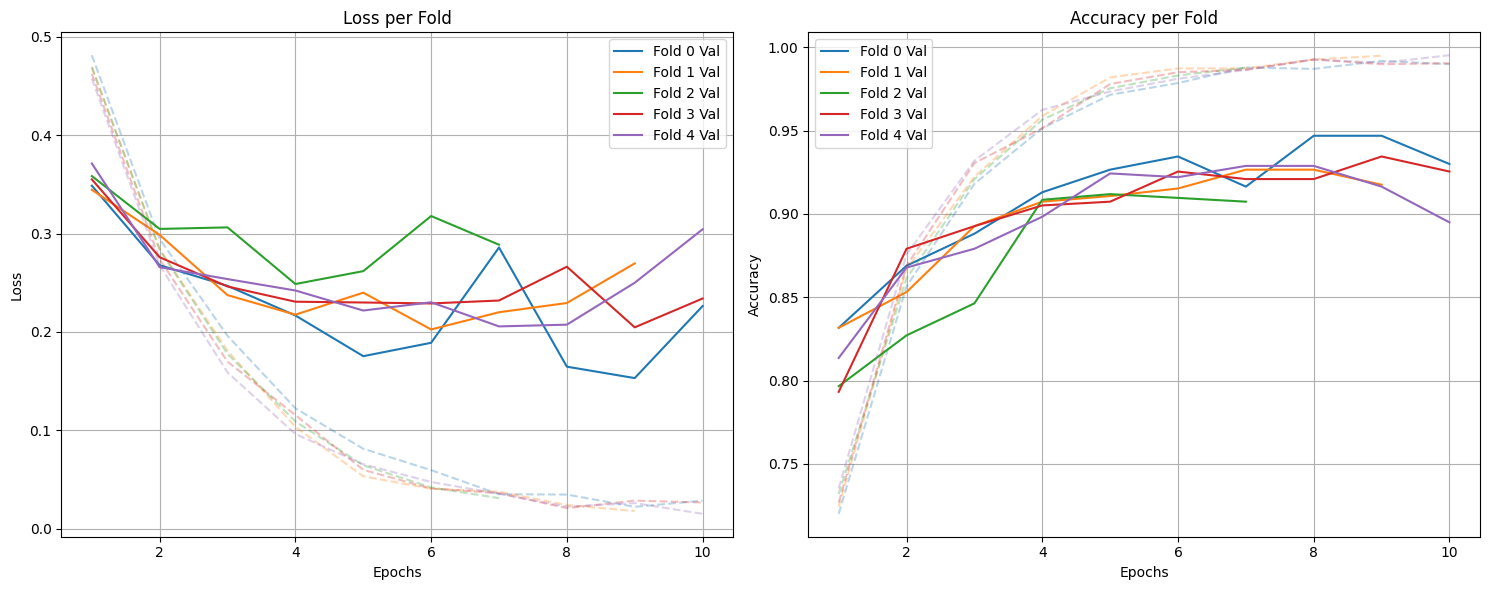

Starting Ensemble Inference for 5 folds...
 -> Loading weights from: best_model/bm_fold_0.pt
 -> Loading weights from: best_model/bm_fold_1.pt
 -> Loading weights from: best_model/bm_fold_2.pt
 -> Loading weights from: best_model/bm_fold_3.pt
 -> Loading weights from: best_model/bm_fold_4.pt
Ensemble predictions saved to submissions/s_final.csv
Deleted best_model/bm_fold_0.pt.
Deleted best_model/bm_fold_1.pt.
Deleted best_model/bm_fold_2.pt.
Deleted best_model/bm_fold_3.pt.
Deleted best_model/bm_fold_4.pt.


In [ ]:
try:
    load_csv_and_augment(use_aug=['backtr'])
    train(
        'BERTweet',
        'vinai/bertweet-base',
        head=torch.nn.Sequential(
            torch.nn.Dropout(0.5),
            torch.nn.Linear(768, 1),
            torch.nn.Sigmoid()
        ),
        token_pooling='mean',
        layer_pooling='attn',
        layers_to_use=[9, 10, 11],
        n_splits=5,
        pos_weight=0.8,
        appendix='final',
    )
except:
  pass

# reset
load_csv_and_augment(use_aug=[])